# Wind-tunnel analysis notebook — cleaned version

This notebook is a consolidated version of the current analysis workflow. It is intended to replace the repeated code blocks across the previous notebooks.

Main features:

- reads all `.lvm` files in one folder,
- parses clean and trip-wire filenames,
- computes mean \(C_p(\theta)\), \(C_D\), \(C_L\), RMS/variance of \(C_p\),
- computes Strouhal number from the time-resolved lift signal,
- stores everything in both `results_df` and `grouped_results`,
- includes reusable plotting functions for \(C_p\), \(C_D\) vs Re, \(C_L\) vs Re, normal-bar \(C_p\) plots, and batch uncertainty.

Expected filename formats:

```text
Cyl100v2_Re100k_Clean.lvm
Cyl100v2_Re100k_Trip_0.94_A27.lvm
```

Older names such as `Cyl100_Re100k_Clean.lvm` should also work, as long as the general structure is the same.


## 1. Imports and user settings

In [28]:
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# FIGURE FONT SETTINGS
# =========================
# Match this to the main text size in your LaTeX document.
# Examples:
#   \documentclass[10pt]{...} -> FIG_FONT_SIZE = 10
#   \documentclass[11pt]{...} -> FIG_FONT_SIZE = 11
#   \documentclass[12pt]{...} -> FIG_FONT_SIZE = 12
FIG_FONT_SIZE = 14

plt.rcParams.update({
    "font.size": FIG_FONT_SIZE,
    "axes.labelsize": FIG_FONT_SIZE,
    "axes.titlesize": FIG_FONT_SIZE,
    "xtick.labelsize": FIG_FONT_SIZE,
    "ytick.labelsize": FIG_FONT_SIZE,
    "legend.fontsize": FIG_FONT_SIZE,
    "figure.titlesize": FIG_FONT_SIZE,
})

# =========================
# REYNOLDS NUMBER AXIS SETTINGS
# =========================
# Re values are stored internally as full values, e.g. 100000.
# For plots, they are displayed as Re/1000, e.g. 100 for Re = 100000.
RE_AXIS_SCALE = 1000.0
RE_AXIS_LABEL = r"$Re \times 10^{3}$"

def re_axis_values(re_values):
    """Return Reynolds numbers scaled for plotting on the x-axis."""
    return np.asarray(re_values, dtype=float) / RE_AXIS_SCALE


# =========================
# USER SETTINGS
# =========================
# Default: use the folder where the notebook is opened from.
# If this does not find your .lvm files, replace Path.cwd() with your LVM folder, e.g.
# DATA_FOLDER = Path(r"C:\Users\mpciv\Downloads\LVM-20260514T000837Z-3-001\LVM")
DATA_FOLDER = Path(r"C:\Users\mpciv\Downloads\LVM-20260319T152800Z-3-001\LVM")

# Output folder for optional exported figures/tables.
OUTPUT_FOLDER = DATA_FOLDER / "processed_outputs"
OUTPUT_FOLDER.mkdir(exist_ok=True)

# Cylinder diameter [m].
D = 0.100

# 1-based pressure tap columns in the .lvm files.
# Layer 1: 0, 12, 24, ..., 348 degrees
# Layer 2: 6, 18, 30, ..., 354 degrees
LAYER1_COLS_1BASED = (1, 30)
LAYER2_COLS_1BASED = (33, 62)

# Extra channels. The first of these, "pitot", is used as q_inf.
EXTRA_NAMES = ["pitot", "AoA", "F", "alpha", "P_m", "V_tunnel", "rho", "time"]

# FFT settings for Strouhal estimation from C_L(t).
REMOVE_FIRST_FRAC = 0.10
F_MIN = 1.0
F_MAX = 500.0

# Strouhal estimation method used in results_df and St-vs-Re plots.
# "single": one FFT on the full signal after removing the initial transient.
# "segments": split the remaining signal into ST_N_SEGMENTS sections and use the
#             mean/median of the dominant frequencies. This is the default here.
ST_METHOD = "segments"
ST_N_SEGMENTS = 5
ST_SEGMENT_STATISTIC = "mean"   # choose "mean" or "median"

# Batch uncertainty settings for C_D and C_L.
N_BATCHES = 5

print(f"Using DATA_FOLDER: {DATA_FOLDER}")
print(f"Number of .lvm files found: {len(list(DATA_FOLDER.glob('*.lvm')))}")


Using DATA_FOLDER: C:\Users\mpciv\Downloads\LVM-20260319T152800Z-3-001\LVM
Number of .lvm files found: 61


## 2. Helper functions

In [2]:
def read_lvm_file(file_path: Path) -> pd.DataFrame:
    """Read an LVM file with whitespace-separated columns."""
    return pd.read_csv(file_path, sep=r"\s+", header=None, engine="python")


def extract_1based_inclusive(df: pd.DataFrame, start: int, end: int) -> np.ndarray:
    """Extract columns using 1-based inclusive indexing."""
    return df.iloc[:, start - 1:end].to_numpy()


def re_label_to_int(re_label: str) -> int:
    """Convert e.g. 'Re100k' to 100000."""
    return int(re_label.replace("Re", "").replace("k", "")) * 1000


def re_value_from_run(run_dict: dict) -> int:
    """Sorting helper for run dictionaries."""
    return re_label_to_int(run_dict["re"])


def parse_filename(file_path: Path) -> dict:
    """
    Parse file names such as:
    - Cyl100v2_Re100k_Clean.lvm
    - Cyl100v2_Re100k_Trip_0.94_A27.lvm
    """
    parts = file_path.stem.split("_")

    if len(parts) < 3:
        raise ValueError(f"Unexpected filename format: {file_path.name}")

    meta = {
        "file": file_path.name,
        "file_path": file_path,
        "cylinder": parts[0],
        "re": parts[1],                # e.g. Re100k
        "Re": re_label_to_int(parts[1]),
        "case": None,
        "trip_mm": None,
        "angle": None,
        "key": None,
    }

    if len(parts) == 3 and parts[2] == "Clean":
        meta["case"] = "Clean"
        meta["key"] = ("Clean",)

    elif len(parts) == 5 and parts[2] == "Trip":
        meta["case"] = "Trip"
        meta["trip_mm"] = float(parts[3])
        meta["angle"] = int(parts[4].replace("A", ""))
        meta["key"] = ("Trip", f"{meta['trip_mm']:.2f}", str(meta["angle"]))

    else:
        raise ValueError(f"Unexpected filename format: {file_path.name}")

    return meta


def combine_tap_layers(layer1_values: np.ndarray, layer2_values: np.ndarray):
    """
    Combine the two pressure tap layers into one ordered circumferential distribution.

    For this dataset:
    - Layer 2 corresponds to 0, 12, 24, ..., 348 degrees
    - Layer 1 corresponds to 6, 18, 30, ..., 354 degrees
    """
    theta1 = np.arange(6.0, 360.0, 12.0)   # layer 1
    theta2 = np.arange(0.0, 360.0, 12.0)   # layer 2

    theta = np.r_[theta1, theta2]
    values = np.concatenate([layer1_values, layer2_values], axis=-1)

    order = np.argsort(theta)
    return theta[order], values[..., order]


def close_periodic_distribution(theta_deg: np.ndarray, values: np.ndarray):
    """Repeat the first point at 360 degrees to close a periodic distribution."""
    theta_closed = np.r_[theta_deg, 360.0]

    if values.ndim == 1:
        values_closed = np.r_[values, values[0]]
    else:
        values_closed = np.concatenate([values, values[..., [0]]], axis=-1)

    return theta_closed, values_closed


def integrate_cd_cl(theta_deg_closed: np.ndarray, cp_closed: np.ndarray):
    """
    Integrate C_p around the cylinder.

    Sign convention matches the previous notebooks:
        C_D = 0.5 * integral(C_p cos(theta) dtheta)
        C_L = 0.5 * integral(C_p sin(theta) dtheta)

    If your angle convention changes later, this is the function to check.
    """
    theta_rad = np.deg2rad(theta_deg_closed)

    C_D = 0.5 * np.trapz(cp_closed * np.cos(theta_rad), theta_rad, axis=-1)
    C_L = 0.5 * np.trapz(cp_closed * np.sin(theta_rad), theta_rad, axis=-1)

    return C_D, C_L


def batch_confidence_interval(values: np.ndarray, n_batches: int = 5, confidence: float = 0.95):
    """
    Estimate finite-sampling uncertainty by splitting a time signal into batches.

    Returns:
        batch_means, mean, std, error
    where error is the half-width of the confidence interval.
    """
    values = np.asarray(values, dtype=float)
    batches = np.array_split(values, n_batches)
    batch_means = np.array([batch.mean() for batch in batches])

    mean = batch_means.mean()
    std = batch_means.std(ddof=1)

    # Student-t multiplier. Use scipy if available; otherwise use common values.
    try:
        from scipy.stats import t
        t_value = t.ppf(0.5 + confidence / 2.0, df=n_batches - 1)
    except Exception:
        if confidence == 0.95 and n_batches == 5:
            t_value = 2.776
        else:
            t_value = 1.96

    error = t_value * std / np.sqrt(n_batches)
    return batch_means, mean, std, error


def dominant_frequency_fft(time: np.ndarray, signal: np.ndarray,
                           remove_first_frac: float = 0.10,
                           f_min: float = 1.0,
                           f_max: float = 500.0):
    """
    Find dominant frequency using FFT with a Hann window.

    Returns:
        f_dom, freqs_band, amplitude_band
    """
    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)

    valid = np.isfinite(time) & np.isfinite(signal)
    time = time[valid]
    signal = signal[valid]

    start_idx = int(remove_first_frac * len(time))
    time = time[start_idx:]
    signal = signal[start_idx:]

    if len(time) < 10:
        raise ValueError("Too few samples for FFT.")

    signal = signal - np.mean(signal)
    dt = np.mean(np.diff(time))

    if not np.isfinite(dt) or dt <= 0:
        raise ValueError("Invalid time step. Check the time column.")

    window = np.hanning(len(signal))
    fft_vals = np.fft.rfft(signal * window)
    freqs = np.fft.rfftfreq(len(signal), d=dt)
    amplitude = np.abs(fft_vals)

    # Remove zero frequency and apply useful frequency band.
    freqs = freqs[1:]
    amplitude = amplitude[1:]

    band_mask = (freqs >= f_min) & (freqs <= f_max)
    freqs_band = freqs[band_mask]
    amplitude_band = amplitude[band_mask]

    if len(freqs_band) == 0:
        raise ValueError(f"No FFT frequencies inside selected band {f_min}–{f_max} Hz.")

    dominant_idx = np.argmax(amplitude_band)
    f_dom = freqs_band[dominant_idx]

    return f_dom, freqs_band, amplitude_band


def dominant_frequency_fft_segments(time: np.ndarray,
                                    signal: np.ndarray,
                                    n_segments: int = 5,
                                    remove_first_frac: float = 0.10,
                                    f_min: float = 1.0,
                                    f_max: float = 500.0,
                                    statistic: str = "mean"):
    """
    Estimate the dominant shedding frequency from segmented FFTs.

    The function first removes the initial transient fraction from the full signal,
    then splits the remaining signal into n_segments. A dominant frequency is found
    in each segment. The returned frequency is either the mean or median of the
    segment peak frequencies.

    Returns:
        f_summary: mean/median dominant frequency [Hz]
        f_segments: array of dominant frequencies for each segment [Hz]
    """
    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)

    valid = np.isfinite(time) & np.isfinite(signal)
    time = time[valid]
    signal = signal[valid]

    start_idx = int(remove_first_frac * len(time))
    time_cut = time[start_idx:]
    signal_cut = signal[start_idx:]

    if len(time_cut) < 10 * n_segments:
        raise ValueError("Too few samples for segmented FFT.")

    time_segments = np.array_split(time_cut, n_segments)
    signal_segments = np.array_split(signal_cut, n_segments)

    f_segments = []
    for t_seg, s_seg in zip(time_segments, signal_segments):
        f_dom, _, _ = dominant_frequency_fft(
            t_seg,
            s_seg,
            remove_first_frac=0.0,
            f_min=f_min,
            f_max=f_max,
        )
        f_segments.append(f_dom)

    f_segments = np.asarray(f_segments, dtype=float)

    if statistic == "mean":
        f_summary = np.nanmean(f_segments)
    elif statistic == "median":
        f_summary = np.nanmedian(f_segments)
    else:
        raise ValueError('statistic must be either "mean" or "median".')

    return f_summary, f_segments


def config_label_from_row(row) -> str:
    """Human-readable label for plotting."""
    if row["case"] == "Clean":
        return "Clean"
    return f'A{int(row["angle"])}'




def t_value_975(df):
    """
    Approximate two-sided Student-t value for 95% confidence interval.
    Used for small batch counts.
    """
    table = {
        1: 12.706,
        2: 4.303,
        3: 3.182,
        4: 2.776,
        5: 2.571,
        6: 2.447,
        7: 2.365,
        8: 2.306,
        9: 2.262,
        10: 2.228,
    }

    if df in table:
        return table[df]
    elif df > 30:
        return 1.96
    else:
        return table[10]


def cl_batch_uncertainty_for_run(run,
                                 n_batches=5,
                                 remove_first_frac=REMOVE_FIRST_FRAC):
    """
    Compute batch-mean uncertainty for C_L(t).

    Returns:
        batch_df, mean_CL, std_CL, ci95_CL
    """

    time = np.asarray(run["time"], dtype=float)
    C_L_t = np.asarray(run["C_L_t"], dtype=float)

    start_idx = int(remove_first_frac * len(time))
    C_L_cut = C_L_t[start_idx:]

    batches = np.array_split(C_L_cut, n_batches)

    batch_values = []
    for i, batch in enumerate(batches, start=1):
        batch_values.append({
            "batch": i,
            "C_L_mean": np.nanmean(batch),
        })

    batch_df = pd.DataFrame(batch_values)

    mean_CL = batch_df["C_L_mean"].mean()
    std_CL = batch_df["C_L_mean"].std(ddof=1)

    t_val = t_value_975(n_batches - 1)
    ci95_CL = t_val * std_CL / np.sqrt(n_batches)

    return batch_df, mean_CL, std_CL, ci95_CL


def st_segment_uncertainty_for_run(run,
                                   n_segments=5,
                                   remove_first_frac=REMOVE_FIRST_FRAC,
                                   f_min=F_MIN,
                                   f_max=F_MAX,
                                   diameter=D):
    """
    Compute segmented FFT uncertainty for St.

    Returns:
        segment_df, mean_St, std_St
    """

    time = np.asarray(run["time"], dtype=float)
    C_L_t = np.asarray(run["C_L_t"], dtype=float)
    U_tunnel = run["extra_data"]["V_tunnel"].to_numpy(dtype=float)

    start_idx = int(remove_first_frac * len(time))

    time_cut = time[start_idx:]
    C_L_cut = C_L_t[start_idx:]
    U_cut = U_tunnel[start_idx:]

    time_segments = np.array_split(time_cut, n_segments)
    lift_segments = np.array_split(C_L_cut, n_segments)
    U_segments = np.array_split(U_cut, n_segments)

    segment_values = []

    for i, (t_seg, cl_seg, U_seg) in enumerate(
        zip(time_segments, lift_segments, U_segments),
        start=1
    ):
        f_dom, freqs, amp = dominant_frequency_fft(
            t_seg,
            cl_seg,
            remove_first_frac=0.0,
            f_min=f_min,
            f_max=f_max,
        )

        U_mean = np.nanmean(U_seg)
        St = f_dom * diameter / U_mean

        segment_values.append({
            "segment": i,
            "f_shedding": f_dom,
            "U_mean": U_mean,
            "St": St,
        })

    segment_df = pd.DataFrame(segment_values)

    mean_St = segment_df["St"].mean()
    std_St = segment_df["St"].std(ddof=1)

    return segment_df, mean_St, std_St


## 3. Read all `.lvm` files and compute results

In [3]:
def process_lvm_file(file_path: Path,
                     diameter: float = D,
                     n_batches: int = N_BATCHES) -> dict:
    """Read one LVM file and return a complete run dictionary."""
    meta = parse_filename(file_path)
    df = read_lvm_file(file_path)

    # Pressure tap layers.
    layer1 = extract_1based_inclusive(df, *LAYER1_COLS_1BASED)
    layer2 = extract_1based_inclusive(df, *LAYER2_COLS_1BASED)

    # Extra channels.
    extra_data = df.iloc[:, 63:71].copy()
    extra_data.columns = EXTRA_NAMES

    q_inf = extra_data["pitot"].to_numpy(dtype=float)
    time = extra_data["time"].to_numpy(dtype=float)
    U_tunnel = extra_data["V_tunnel"].to_numpy(dtype=float)

    # Avoid division by zero.
    q_safe = np.where(np.abs(q_inf) < 1e-12, np.nan, q_inf)

    # Time-resolved pressure coefficients.
    cp1_t = layer1 / q_safe[:, None]
    cp2_t = layer2 / q_safe[:, None]

    theta, cp_t = combine_tap_layers(cp1_t, cp2_t)
    theta_closed, cp_t_closed = close_periodic_distribution(theta, cp_t)

    # Time-resolved force coefficients.
    C_D_t, C_L_t = integrate_cd_cl(theta_closed, cp_t_closed)

    # Mean and fluctuation statistics for Cp.
    cp_mean = np.nanmean(cp_t, axis=0)
    cp_var = np.nanvar(cp_t, axis=0, ddof=1)
    cp_rms = np.sqrt(cp_var)

    theta_closed, cp_mean_closed = close_periodic_distribution(theta, cp_mean)
    _, cp_var_closed = close_periodic_distribution(theta, cp_var)
    _, cp_rms_closed = close_periodic_distribution(theta, cp_rms)

    # Mean CD/CL from time-resolved values.
    C_D_mean = np.nanmean(C_D_t)
    C_L_mean = np.nanmean(C_L_t)

    # Batch uncertainty.
    C_D_batches, C_D_batch_mean, C_D_batch_std, C_D_error = batch_confidence_interval(C_D_t, n_batches=n_batches)
    C_L_batches, C_L_batch_mean, C_L_batch_std, C_L_error = batch_confidence_interval(C_L_t, n_batches=n_batches)

    # Strouhal number from lift signal.
    # The stored St value is controlled by ST_METHOD in the settings cell.
    try:
        # Keep the single full-signal FFT as stored diagnostic data.
        f_single, freqs_band, amp_band = dominant_frequency_fft(
            time,
            C_L_t,
            remove_first_frac=REMOVE_FIRST_FRAC,
            f_min=F_MIN,
            f_max=F_MAX,
        )

        start_idx = int(REMOVE_FIRST_FRAC * len(U_tunnel))
        U_mean_for_st = np.nanmean(U_tunnel[start_idx:])
        St_single = f_single * diameter / U_mean_for_st

        if ST_METHOD == "single":
            f_shedding = f_single
            f_shedding_segments = np.array([])
            St_segments = np.array([])

        elif ST_METHOD == "segments":
            f_shedding, f_shedding_segments = dominant_frequency_fft_segments(
                time,
                C_L_t,
                n_segments=ST_N_SEGMENTS,
                remove_first_frac=REMOVE_FIRST_FRAC,
                f_min=F_MIN,
                f_max=F_MAX,
                statistic=ST_SEGMENT_STATISTIC,
            )
            St_segments = f_shedding_segments * diameter / U_mean_for_st

        else:
            raise ValueError('ST_METHOD must be either "single" or "segments".')

        St = f_shedding * diameter / U_mean_for_st
        f_shedding_std = (
            np.nanstd(f_shedding_segments, ddof=1)
            if len(f_shedding_segments) > 1 else np.nan
        )
        St_std = (
            np.nanstd(St_segments, ddof=1)
            if len(St_segments) > 1 else np.nan
        )

    except Exception as exc:
        f_shedding = np.nan
        f_single = np.nan
        St = np.nan
        St_single = np.nan
        f_shedding_std = np.nan
        St_std = np.nan
        f_shedding_segments = np.array([])
        St_segments = np.array([])
        freqs_band = np.array([])
        amp_band = np.array([])
        print(f"Could not compute Strouhal number for {file_path.name}: {exc}")

    run = {
        **meta,
        "file_name": file_path.name,
        "theta": theta_closed,
        "cp": cp_mean_closed,
        "cp_var": cp_var_closed,
        "cp_rms": cp_rms_closed,
        "C_D": C_D_mean,
        "C_L": C_L_mean,
        "C_D_error": C_D_error,
        "C_L_error": C_L_error,
        "C_D_batches": C_D_batches,
        "C_L_batches": C_L_batches,
        "St": St,
        "St_std": St_std,
        "St_single": St_single,
        "St_segments": St_segments,
        "f_shedding": f_shedding,
        "f_shedding_std": f_shedding_std,
        "f_shedding_single": f_single,
        "f_shedding_segments": f_shedding_segments,
        "q_inf_mean": np.nanmean(q_inf),
        "U_mean": np.nanmean(U_tunnel),
        "rho_mean": np.nanmean(extra_data["rho"]),
        "time": time,
        "C_D_t": C_D_t,
        "C_L_t": C_L_t,
        "extra_data": extra_data,
        "fft_freqs": freqs_band,
        "fft_amplitude": amp_band,
    }

    return run


def build_database(data_folder: Path):
    """Read all .lvm files into grouped_results and results_df."""
    runs = []
    grouped_results = defaultdict(list)

    files = sorted(data_folder.glob("*.lvm"), key=lambda p: parse_filename(p)["Re"])

    for file_path in files:
        try:
            run = process_lvm_file(file_path)
        except Exception as exc:
            print(f"Skipping {file_path.name}: {exc}")
            continue

        runs.append(run)
        grouped_results[run["key"]].append(run)

    rows = []
    for run in runs:
        rows.append({
            "file": run["file_name"],
            "Re": run["Re"],
            "re": run["re"],
            "case": run["case"],
            "trip_mm": run["trip_mm"],
            "angle": run["angle"],
            "C_D": run["C_D"],
            "C_D_error": run["C_D_error"],
            "C_L": run["C_L"],
            "C_L_error": run["C_L_error"],
            "St": run["St"],
            "St_std": run["St_std"],
            "St_single": run["St_single"],
            "f_shedding": run["f_shedding"],
            "f_shedding_std": run["f_shedding_std"],
            "f_shedding_single": run["f_shedding_single"],
            "q_inf_mean": run["q_inf_mean"],
            "U_mean": run["U_mean"],
            "rho_mean": run["rho_mean"],
            "key": run["key"],
        })

    results_df = pd.DataFrame(rows)

    if not results_df.empty:
        results_df["config"] = results_df.apply(config_label_from_row, axis=1)
        results_df = results_df.sort_values(["case", "trip_mm", "angle", "Re"], na_position="first")

    return runs, grouped_results, results_df


runs, grouped_results, results_df = build_database(DATA_FOLDER)

print(f"Processed runs: {len(runs)}")
display(results_df)


Processed runs: 61


,file,Re,re,case,trip_mm,angle,C_D,C_D_error,C_L,C_L_error,...,St_std,St_single,f_shedding,f_shedding_std,f_shedding_single,q_inf_mean,U_mean,rho_mean,key,config
0,Cyl100_Re050k_Clean.lvm,50000,Re050k,Clean,NaN,NaN,1.270581,0.050316,-0.008814,0.012070,...,0.005499,0.196543,15.018259,0.410892,14.685830,33.411589,7.470972,1.197358,"(Clean,)",Clean
13,Cyl100_Re100k_Clean.lvm,100000,Re100k,Clean,NaN,NaN,1.326407,0.036291,-0.004293,0.004166,...,0.003017,0.202162,30.424492,0.455639,30.535498,136.664528,15.107135,1.197358,"(Clean,)",Clean
25,Cyl100_Re150k_Clean.lvm,150000,Re150k,Clean,NaN,NaN,1.390716,0.035389,-0.010321,0.003567,...,0.005824,0.192650,44.445009,1.308411,43.280782,302.131189,22.464136,1.197358,"(Clean,)",Clean
37,Cyl100_Re200k_Clean.lvm,200000,Re200k,Clean,NaN,NaN,1.329857,0.019940,-0.005331,0.003794,...,0.001238,0.199559,60.240970,0.372463,60.019251,541.472817,30.073569,1.197358,"(Clean,)",Clean
49,Cyl100_Re250k_Clean.lvm,250000,Re250k,Clean,NaN,NaN,1.233688,0.006162,-0.001484,0.005609,...,0.001426,0.208493,78.084773,0.537534,78.583058,850.185461,37.682543,1.197358,"(Clean,)",Clean
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10,Cyl100_Re050k_Trip_0.94_A69.lvm,50000,Re050k,Trip,0.94,69.0,1.000548,0.007605,-0.027020,0.011620,...,0.038925,0.134303,9.033115,2.923226,10.086047,33.791097,7.511607,1.197358,"(Trip, 0.94, 69)",A69
24,Cyl100_Re100k_Trip_0.94_A69.lvm,100000,Re100k,Trip,0.94,69.0,1.006997,0.004984,0.002435,0.007022,...,0.054998,0.140889,15.683277,8.307163,21.280555,136.575786,15.103788,1.197358,"(Trip, 0.94, 69)",A69
36,Cyl100_Re150k_Trip_0.94_A69.lvm,150000,Re150k,Trip,0.94,69.0,1.032533,0.004662,0.008268,0.003147,...,0.007450,0.148853,34.193021,1.692021,33.805193,308.745260,22.709003,1.197358,"(Trip, 0.94, 69)",A69
48,Cyl100_Re200k_Trip_0.94_A69.lvm,200000,Re200k,Trip,0.94,69.0,1.030541,0.003480,0.004858,0.001328,...,0.044722,0.148466,38.404351,13.488077,44.777665,544.472634,30.155625,1.197358,"(Trip, 0.94, 69)",A69


## 4. Quick checks

In [4]:
# Available grouped keys.
# Clean case: ("Clean",)
# Trip case:  ("Trip", "0.94", "27"), etc.
for key in sorted(grouped_results.keys(), key=str):
    print(key, "->", len(grouped_results[key]), "run(s)")


('Clean',) -> 5 run(s)
('Trip', '0.15', '57') -> 5 run(s)
('Trip', '0.15', '63') -> 5 run(s)
('Trip', '0.15', '69') -> 6 run(s)
('Trip', '0.94', '27') -> 5 run(s)
('Trip', '0.94', '33') -> 5 run(s)
('Trip', '0.94', '39') -> 5 run(s)
('Trip', '0.94', '45') -> 5 run(s)
('Trip', '0.94', '51') -> 5 run(s)
('Trip', '0.94', '57') -> 5 run(s)
('Trip', '0.94', '63') -> 5 run(s)
('Trip', '0.94', '69') -> 5 run(s)


In [5]:
# Optional: export the computed summary table.
if not results_df.empty:
    results_df.to_csv(OUTPUT_FOLDER / "results_summary.csv", index=False)
    print(f"Saved: {OUTPUT_FOLDER / 'results_summary.csv'}")


Saved: C:\Users\mpciv\Downloads\LVM-20260319T152800Z-3-001\LVM\processed_outputs\results_summary.csv


## 5. Plotting functions

In [34]:
def get_runs(target_key, target_re=None):
    """
    Get one or more runs from grouped_results.

    Examples:
        get_runs(("Clean",))
        get_runs(("Trip", "0.94", "27"), target_re="Re100k")
    """
    if target_key not in grouped_results:
        raise ValueError(f"No files found for group {target_key}")

    selected = sorted(grouped_results[target_key], key=re_value_from_run)

    if target_re is not None:
        selected = [run for run in selected if run["re"] == target_re]

    if not selected:
        raise ValueError(f"No files found for group {target_key} with Reynolds number {target_re}")

    return selected


def get_single_run(target_key, target_re):
    """Get exactly one run."""
    selected = get_runs(target_key, target_re=target_re)

    if len(selected) != 1:
        raise ValueError(f"Expected exactly one run, but found {len(selected)}.")

    return selected[0]


def trip_angles_from_key(target_key):
    """Return the two symmetric trip-wire angles for a trip case."""
    if target_key[0] != "Trip":
        return []
    angle = float(target_key[2])
    return [angle, 360.0 - angle]


def plot_cp_distribution(target_key,
                         target_re=None,
                         ylim=(-3.0, 1.2),
                         show_trip_markers=True,
                         show_title=True):
    """Plot C_p(theta) for all Reynolds numbers in a group, or for one selected Re."""
    selected = get_runs(target_key, target_re=target_re)

    fig, ax = plt.subplots(figsize=(9, 6))

    for run in selected:
        ax.plot(run["theta"], run["cp"], "o-", label=run["re"])

    if show_trip_markers and target_key[0] == "Trip":
        for angle in trip_angles_from_key(target_key):
            ax.axvline(angle, color="black", linestyle="--", linewidth=1.3)
        ax.text(
            trip_angles_from_key(target_key)[0],
            ylim[1],
            " trip",
            va="top",
            ha="left",
            fontsize=FIG_FONT_SIZE,
        )

    ax.set_xlabel("Angle [deg]")
    ax.set_ylabel("$C_p$")
    if show_title:
        ax.set_title(f"$C_p$ distribution — {target_key}")
    ax.set_ylim(*ylim)
    ax.grid(True)
    ax.legend(title="Re", loc="best")
    plt.show()

def add_value_labels(ax,
                     x_values,
                     y_values,
                     fmt="{:.2f}",
                     y_offset=8,
                     fontsize=FIG_FONT_SIZE,
                     label_every=1):
    """
    Add small value labels above plotted data points.
    """
    for i, (x, y) in enumerate(zip(x_values, y_values)):
        if i % label_every != 0:
            continue

        if not np.isfinite(x) or not np.isfinite(y):
            continue

        ax.annotate(
            fmt.format(y),
            xy=(x, y),
            xytext=(0, y_offset),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=fontsize,
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="0.75",
                alpha=0.9,
            ),
        )


def plot_cd_vs_re(results_df,
                  trip_mm=None,
                  include_clean=True,
                  angles=None,
                  annotate=False,
                  ylim=None,
                  show_errorbars=True,
                  show_values=False,
                  value_fmt="{:.2f}",
                  label_every=1,
                  title=None,
                  show_title=True):
    """
    Plot C_D vs Reynolds number.

    trip_mm can be:
        - single value, e.g. 0.94
        - list of values, e.g. [0.15, 0.94]
        - None, meaning all trip-wire sizes

    annotate is kept as a backwards-compatible alias for show_values.
    """
    show_values = show_values or annotate

    fig, ax = plt.subplots(figsize=(9, 6))

    # -------------------------
    # Clean cylinder
    # -------------------------
    if include_clean:
        clean_df = results_df[results_df["case"] == "Clean"].sort_values("Re")

        if not clean_df.empty:
            if show_errorbars and "C_D_error" in clean_df.columns:
                ax.errorbar(
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_D"],
                    yerr=clean_df["C_D_error"],
                    fmt="o-",
                    color="black",
                    linewidth=2.4,
                    markersize=7,
                    capsize=4,
                    label="Smooth",
                )
            else:
                ax.plot(
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_D"],
                    "o-",
                    color="black",
                    linewidth=2.4,
                    markersize=7,
                    label="Smooth",
                )

            if show_values:
                add_value_labels(
                    ax,
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_D"],
                    fmt=value_fmt,
                    y_offset=8,
                    fontsize=FIG_FONT_SIZE,
                    label_every=label_every,
                )

    # -------------------------
    # Trip-wire cases
    # -------------------------
    trip_df = results_df[results_df["case"] == "Trip"].copy()

    # Filter by trip-wire size.
    if trip_mm is not None:
        if isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            mask = np.zeros(len(trip_df), dtype=bool)
            for t in trip_mm:
                mask |= np.isclose(trip_df["trip_mm"], float(t))
            trip_df = trip_df[mask]
        else:
            trip_df = trip_df[np.isclose(trip_df["trip_mm"], float(trip_mm))]

    # Filter by trip-wire angle.
    if angles is not None:
        trip_df = trip_df[trip_df["angle"].isin(angles)]

    # Include trip diameter in label when more than one diameter is shown.
    if trip_df.empty:
        show_wire_in_label = False
    else:
        show_wire_in_label = trip_df["trip_mm"].nunique(dropna=True) > 1

    # Important: group by both trip size and angle.
    for (wire_size, angle), group in trip_df.groupby(["trip_mm", "angle"]):
        group = group.sort_values("Re")

        if show_wire_in_label:
            label = f"{wire_size:.2f} mm, A{int(angle)}"
        else:
            label = f"A{int(angle)}"

        if show_errorbars and "C_D_error" in group.columns:
            ax.errorbar(
                re_axis_values(group["Re"]),
                group["C_D"],
                yerr=group["C_D_error"],
                fmt="o-",
                linewidth=1.8,
                markersize=6,
                capsize=4,
                label=label,
            )
        else:
            ax.plot(
                re_axis_values(group["Re"]),
                group["C_D"],
                "o-",
                linewidth=1.8,
                markersize=6,
                label=label,
            )

        if show_values:
            add_value_labels(
                ax,
                re_axis_values(group["Re"]),
                group["C_D"],
                fmt=value_fmt,
                y_offset=8,
                fontsize=FIG_FONT_SIZE,
                label_every=label_every,
            )

    ax.set_xlabel(RE_AXIS_LABEL)
    ax.set_ylabel("$C_D$")

    if title is None:
        if trip_mm is None:
            title = "$C_D$ vs Reynolds number"
        elif isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            title = "$C_D$ vs Reynolds number — multiple trip-wire sizes"
        else:
            title = f"$C_D$ vs Reynolds number — trip wire {float(trip_mm):.2f} mm"

    if show_title:
        ax.set_title(title)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True)
    ax.legend(title="Configuration", loc="upper right", fontsize=FIG_FONT_SIZE - 4)
    plt.tight_layout()
    plt.show()

def plot_cl_vs_re(results_df,
                  trip_mm=None,
                  include_clean=True,
                  angles=None,
                  annotate=False,
                  ylim=None,
                  show_errorbars=True,
                  show_values=False,
                  value_fmt="{:.3f}",
                  label_every=1,
                  title=None,
                  show_title=True):
    """
    Plot C_L vs Reynolds number.

    annotate is kept as a backwards-compatible alias for show_values.
    """
    show_values = show_values or annotate

    fig, ax = plt.subplots(figsize=(9, 6))

    if include_clean:
        clean_df = results_df[results_df["case"] == "Clean"].sort_values("Re")
        if not clean_df.empty:
            if show_errorbars and "C_L_error" in clean_df.columns:
                ax.errorbar(
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_L"],
                    yerr=clean_df["C_L_error"],
                    fmt="o-",
                    color="maroon",
                    linewidth=2.4,
                    markersize=7,
                    capsize=4,
                    label="Smooth",
                )
            else:
                ax.plot(re_axis_values(clean_df["Re"]), clean_df["C_L"], "o-", color="maroon", linewidth=2.4, label="Smooth")

            if show_values:
                add_value_labels(
                    ax,
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_L"],
                    fmt=value_fmt,
                    y_offset=8,
                    fontsize=FIG_FONT_SIZE,
                    label_every=label_every,
                )

    trip_df = results_df[results_df["case"] == "Trip"].copy()

    if trip_mm is not None:
        if isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            mask = np.zeros(len(trip_df), dtype=bool)
            for t in trip_mm:
                mask |= np.isclose(trip_df["trip_mm"], float(t))
            trip_df = trip_df[mask]
        else:
            trip_df = trip_df[np.isclose(trip_df["trip_mm"], float(trip_mm))]

    if angles is not None:
        trip_df = trip_df[trip_df["angle"].isin(angles)]

    show_wire_in_label = (not trip_df.empty) and trip_df["trip_mm"].nunique(dropna=True) > 1

    for (wire_size, angle), group in trip_df.groupby(["trip_mm", "angle"]):
        group = group.sort_values("Re")
        label = f"{wire_size:.2f} mm, A{int(angle)}" if show_wire_in_label else f"A{int(angle)}"

        if show_errorbars and "C_L_error" in group.columns:
            ax.errorbar(
                re_axis_values(group["Re"]),
                group["C_L"],
                yerr=group["C_L_error"],
                fmt="o-",
                linewidth=1.8,
                markersize=6,
                capsize=4,
                label=label,
            )
        else:
            ax.plot(re_axis_values(group["Re"]), group["C_L"], "o-", label=label)

        if show_values:
            add_value_labels(
                ax,
                re_axis_values(group["Re"]),
                group["C_L"],
                fmt=value_fmt,
                y_offset=8,
                fontsize=FIG_FONT_SIZE,
                label_every=label_every,
            )

    ax.axhline(0.0, color="0.3", linewidth=1.0)
    ax.set_xlabel(RE_AXIS_LABEL)
    ax.set_ylabel("$C_L$")

    if title is None:
        title = "$C_L$ vs Reynolds number"

    if show_title:
        ax.set_title(title)

    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(True)
    ax.legend(title="Configuration")
    plt.tight_layout()
    plt.show()

def plot_st_vs_re(results_df,
                  trip_mm=None,
                  include_clean=True,
                  angles=None,
                  annotate=False,
                  ylim=None,
                  show_values=False,
                  value_fmt="{:.3f}",
                  label_every=1,
                  show_errorbars=False,
                  error_capsize=4,
                  title=None,
                  show_title=True):
    """
    Plot segmented Strouhal number vs Reynolds number.

    In the segmented notebooks, results_df['St'] is the mean of the segment peaks.
    show_errorbars=True uses results_df['St_std'], i.e. the spread between segments.
    annotate is kept as a backwards-compatible alias for show_values.
    """
    show_values = show_values or annotate

    fig, ax = plt.subplots(figsize=(9, 6))

    if include_clean:
        clean_df = results_df[results_df["case"] == "Clean"].sort_values("Re")
        if not clean_df.empty:
            if show_errorbars and "St_std" in clean_df.columns:
                ax.errorbar(
                    re_axis_values(clean_df["Re"]),
                    clean_df["St"],
                    yerr=clean_df["St_std"],
                    fmt="o-",
                    color="black",
                    linewidth=2.4,
                    markersize=7,
                    capsize=error_capsize,
                    label="Smooth",
                )
            else:
                ax.plot(
                    re_axis_values(clean_df["Re"]),
                    clean_df["St"],
                    "o-",
                    color="black",
                    linewidth=2.4,
                    markersize=7,
                    label="Smooth",
                )

            if show_values:
                add_value_labels(
                    ax,
                    re_axis_values(clean_df["Re"]),
                    clean_df["St"],
                    fmt=value_fmt,
                    y_offset=8,
                    fontsize=FIG_FONT_SIZE,
                    label_every=label_every,
                )

    trip_df = results_df[results_df["case"] == "Trip"].copy()

    if trip_mm is not None:
        if isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            mask = np.zeros(len(trip_df), dtype=bool)
            for t in trip_mm:
                mask |= np.isclose(trip_df["trip_mm"], float(t))
            trip_df = trip_df[mask]
        else:
            trip_df = trip_df[np.isclose(trip_df["trip_mm"], float(trip_mm))]

    if angles is not None:
        trip_df = trip_df[trip_df["angle"].isin(angles)]

    show_wire_in_label = (not trip_df.empty) and trip_df["trip_mm"].nunique(dropna=True) > 1

    for (wire_size, angle), group in trip_df.groupby(["trip_mm", "angle"]):
        group = group.sort_values("Re")
        label = f"{wire_size:.2f} mm, A{int(angle)}" if show_wire_in_label else f"A{int(angle)}"

        if show_errorbars and "St_std" in group.columns:
            ax.errorbar(
                re_axis_values(group["Re"]),
                group["St"],
                yerr=group["St_std"],
                fmt="o-",
                linewidth=1.8,
                markersize=6,
                capsize=error_capsize,
                label=label,
            )
        else:
            ax.plot(
                re_axis_values(group["Re"]),
                group["St"],
                "o-",
                linewidth=1.8,
                markersize=6,
                label=label,
            )

        if show_values:
            add_value_labels(
                ax,
                re_axis_values(group["Re"]),
                group["St"],
                fmt=value_fmt,
                y_offset=8,
                fontsize=FIG_FONT_SIZE,
                label_every=label_every,
            )

    ax.set_xlabel(RE_AXIS_LABEL)
    ax.set_ylabel("$St$")

    if title is None:
        title = "Strouhal number vs Reynolds number"

    if show_title:
        ax.set_title(title)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True)
    ax.legend(title="Configuration", loc="upper left")
    plt.tight_layout()
    plt.show()

def plot_lift_signal_and_fft(target_key,
                             target_re,
                             remove_first_frac=REMOVE_FIRST_FRAC,
                             f_min=F_MIN,
                             f_max=F_MAX,
                             show_title=True):
    """
    Plot C_L(t) and FFT spectrum for one selected run.

    Example:
        plot_lift_signal_and_fft(("Clean",), "Re100k")
        plot_lift_signal_and_fft(("Trip", "0.94", "45"), "Re100k")
    """
    run = get_single_run(target_key, target_re)

    time = np.asarray(run["time"], dtype=float)
    C_L_t = np.asarray(run["C_L_t"], dtype=float)

    start_idx = int(remove_first_frac * len(time))

    time_cut = time[start_idx:]
    C_L_cut = C_L_t[start_idx:]

    f_dom, freqs, amp = dominant_frequency_fft(
        time,
        C_L_t,
        remove_first_frac=remove_first_frac,
        f_min=f_min,
        f_max=f_max,
    )

    St = f_dom * D / np.nanmean(run["extra_data"]["V_tunnel"].to_numpy()[start_idx:])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    # -------------------------
    # Lift signal
    # -------------------------
    ax1.plot(time_cut, C_L_cut, linewidth=1.2, color = "darkorange")
    ax1.axhline(np.nanmean(C_L_cut), color="black", linestyle="--", linewidth=1.0)

    ax1.set_xlabel("Time [s]")
    ax1.set_ylabel("$C_L(t)$")
    if show_title:
        ax1.set_title(f"Lift coefficient signal — {run['file_name']}")
    ax1.grid(True)

    # -------------------------
    # FFT
    # -------------------------
    ax2.plot(freqs, amp, linewidth=1.2, color = "darkorange")
    ax2.axvline(f_dom, color="black", linestyle="--", linewidth=1.2,
                label=f"$f$ = {f_dom:.2f} Hz, $St$ = {St:.3f}")

    ax2.set_xlabel("Frequency [Hz]")
    ax2.set_ylabel("FFT amplitude")
    if show_title:
        ax2.set_title("FFT of $C_L(t)$")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

def plot_lift_fft_segments(target_key,
                           target_re,
                           n_segments=5,
                           remove_first_frac=REMOVE_FIRST_FRAC,
                           f_min=F_MIN,
                           f_max=F_MAX,
                           normalize=True,
                           show_title=True):
    """
    Split C_L(t) into sections and plot one FFT for each section.

    This is useful for checking whether the shedding frequency is stable
    throughout the measurement.
    """
    run = get_single_run(target_key, target_re)

    time = np.asarray(run["time"], dtype=float)
    C_L_t = np.asarray(run["C_L_t"], dtype=float)

    start_idx = int(remove_first_frac * len(time))
    time_cut = time[start_idx:]
    C_L_cut = C_L_t[start_idx:]

    time_segments = np.array_split(time_cut, n_segments)
    lift_segments = np.array_split(C_L_cut, n_segments)

    fig, ax = plt.subplots(figsize=(10, 6))

    dominant_freqs = []

    for i, (t_seg, cl_seg) in enumerate(zip(time_segments, lift_segments), start=1):
        f_dom, freqs, amp = dominant_frequency_fft(
            t_seg,
            cl_seg,
            remove_first_frac=0.0,
            f_min=f_min,
            f_max=f_max,
        )

        dominant_freqs.append(f_dom)

        if normalize and np.nanmax(amp) > 0:
            amp_plot = amp / np.nanmax(amp)
            ylabel = "Normalized FFT amplitude"
        else:
            amp_plot = amp
            ylabel = "FFT amplitude"

        ax.plot(freqs, amp_plot, linewidth=1.1, label=f"Section {i}: {f_dom:.2f} Hz")

    mean_f = np.nanmean(dominant_freqs)
    mean_U = np.nanmean(run["extra_data"]["V_tunnel"].to_numpy()[start_idx:])
    mean_St = mean_f * D / mean_U

    ax.axvline(
        mean_f,
        color="black",
        linestyle="--",
        linewidth=1.4,
        label=f"Mean peak: {mean_f:.2f} Hz, $St$ = {mean_St:.3f}",
    )

    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel(ylabel)
    if show_title:
        ax.set_title(f"Segmented FFT of $C_L(t)$ — {run['file_name']}")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Dominant frequencies by section [Hz]:")
    for i, f in enumerate(dominant_freqs, start=1):
        print(f"Section {i}: {f:.3f} Hz")

    print(f"\nMean frequency: {mean_f:.3f} Hz")
    print(f"Mean Strouhal number: {mean_St:.4f}")

def plot_cp_rms_variance(target_key,
                         target_re,
                         ylim_cp=(-3.5, 1.5),
                         ylim_stats=None,
                         show_title=True):
    """
    Plot mean Cp together with RMS(Cp') and variance(Cp') for one selected run.

    Examples:
        plot_cp_rms_variance(("Clean",), "Re100k")
        plot_cp_rms_variance(("Trip", "0.94", "45"), "Re100k")
    """
    run = get_single_run(target_key, target_re)

    theta = run["theta"]
    cp = run["cp"]
    cp_rms = run["cp_rms"]
    cp_var = run["cp_var"]

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()

    # Mean Cp
    ax1.plot(
        theta,
        cp,
        "o-",
        linewidth=1.8,
        markersize=4.5,
        label=r"$C_p$",
        color = "firebrick"
    )

    # RMS and variance
    ax2.plot(
        theta,
        cp_rms,
        "s-",
        linewidth=1.5,
        markersize=4,
        label=r"RMS($C_p'$)",
        color = "cadetblue"
    )

    ax2.plot(
        theta,
        cp_var,
        "^-",
        linewidth=1.5,
        markersize=4,
        label=r"Var($C_p'$)",
        color = "steelblue"
    )

    ax1.set_xlabel("Angle [deg]")
    ax1.set_ylabel(r"$C_p$")
    ax2.set_ylabel(r"RMS / variance of $C_p'$")

    ax1.set_xlim(0, 360)
    ax1.set_xticks(np.arange(0, 361, 30))

    if ylim_cp is not None:
        ax1.set_ylim(*ylim_cp)

    if ylim_stats is not None:
        ax2.set_ylim(*ylim_stats)

    ax1.grid(True)

    # Combine legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper center", ncol=3, frameon=True)

    if show_title:
        ax1.set_title(f"$C_p$, RMS and variance — {run['file_name']}")

    plt.tight_layout()
    plt.show()

def plot_single_st_vs_re(results_df,
                         trip_mm=None,
                         include_clean=True,
                         angles=None,
                         annotate=False,
                         ylim=None,
                         show_values=False,
                         value_fmt="{:.3f}",
                         label_every=1,
                         title=None,
                         show_title=True):
    """
    Plot the original single full-signal FFT Strouhal number vs Reynolds number.
    Uses results_df['St_single'].

    annotate is kept as a backwards-compatible alias for show_values.
    """
    show_values = show_values or annotate

    fig, ax = plt.subplots(figsize=(9, 6))

    # -------------------------
    # Clean cylinder
    # -------------------------
    if include_clean:
        clean_df = results_df[
            results_df["case"] == "Clean"
        ].sort_values("Re")

        if not clean_df.empty:
            ax.plot(
                re_axis_values(clean_df["Re"]),
                clean_df["St_single"],
                "o-",
                color="black",
                linewidth=2.4,
                markersize=7,
                label="Clean",
            )

            if show_values:
                add_value_labels(
                    ax,
                    re_axis_values(clean_df["Re"]),
                    clean_df["St_single"],
                    fmt=value_fmt,
                    y_offset=8,
                    fontsize=FIG_FONT_SIZE,
                    label_every=label_every,
                )

    # -------------------------
    # Trip-wire cases
    # -------------------------
    trip_df = results_df[
        results_df["case"] == "Trip"
    ].copy()

    if trip_mm is not None:
        if isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            mask = np.zeros(len(trip_df), dtype=bool)
            for t in trip_mm:
                mask |= np.isclose(trip_df["trip_mm"], float(t))
            trip_df = trip_df[mask]
        else:
            trip_df = trip_df[np.isclose(trip_df["trip_mm"], float(trip_mm))]

    if angles is not None:
        trip_df = trip_df[trip_df["angle"].isin(angles)]

    show_wire_in_label = (not trip_df.empty) and trip_df["trip_mm"].nunique(dropna=True) > 1

    for (wire_size, angle), group in trip_df.groupby(["trip_mm", "angle"]):
        group = group.sort_values("Re")
        label = f"{wire_size:.2f} mm, A{int(angle)}" if show_wire_in_label else f"A{int(angle)}"

        ax.plot(
            re_axis_values(group["Re"]),
            group["St_single"],
            "o-",
            linewidth=1.8,
            markersize=6,
            label=label,
        )

        if show_values:
            add_value_labels(
                ax,
                re_axis_values(group["Re"]),
                group["St_single"],
                fmt=value_fmt,
                y_offset=8,
                fontsize=FIG_FONT_SIZE,
                label_every=label_every,
            )

    ax.set_xlabel(RE_AXIS_LABEL)
    ax.set_ylabel("$St$")

    if title is None:
        title = "Strouhal number vs Reynolds number — single full-signal FFT"

    if show_title:
        ax.set_title(title)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True)
    ax.legend(title="Configuration", loc="lower right")
    plt.tight_layout()
    plt.show()

def plot_cl_st_uncertainty_batches(target_key,
                                   target_re,
                                   n_batches=5,
                                   n_segments=5,
                                   remove_first_frac=REMOVE_FIRST_FRAC,
                                   f_min=F_MIN,
                                   f_max=F_MAX,
                                   show_title=True):
    """
    Plot uncertainty batch/segment values for C_L and St for one selected run.

    C_L:
        Batch means with 95% confidence interval.

    St:
        Segmented FFT Strouhal values with ±1 standard deviation.
    """

    run = get_single_run(target_key, target_re)

    # -------------------------
    # C_L batch uncertainty
    # -------------------------
    cl_df, cl_mean, cl_std, cl_ci95 = cl_batch_uncertainty_for_run(
        run,
        n_batches=n_batches,
        remove_first_frac=remove_first_frac,
    )

    # -------------------------
    # St segmented uncertainty
    # -------------------------
    st_df, st_mean, st_std = st_segment_uncertainty_for_run(
        run,
        n_segments=n_segments,
        remove_first_frac=remove_first_frac,
        f_min=f_min,
        f_max=f_max,
    )

    fig, (ax_cl, ax_st) = plt.subplots(1, 2, figsize=(13, 5))

    # =========================
    # C_L plot
    # =========================
    ax_cl.plot(
        cl_df["batch"],
        cl_df["C_L_mean"],
        "o-",
        linewidth=1.8,
        markersize=7,
        label="Batch mean"
    )

    ax_cl.axhline(
        cl_mean,
        linestyle="--",
        linewidth=1.5,
        label=f"Mean = {cl_mean:.4f}"
    )

    ax_cl.axhspan(
        cl_mean - cl_ci95,
        cl_mean + cl_ci95,
        alpha=0.20,
        label=f"95% CI = ±{cl_ci95:.4f}"
    )

    ax_cl.set_xlabel("Batch number")
    ax_cl.set_ylabel(r"$C_L$")
    if show_title:
        ax_cl.set_title(r"$C_L$ batch uncertainty")
    ax_cl.set_xticks(cl_df["batch"])
    ax_cl.grid(True)
    ax_cl.legend()

    # =========================
    # St plot
    # =========================
    ax_st.plot(
        st_df["segment"],
        st_df["St"],
        "o-",
        linewidth=1.8,
        markersize=7,
        label="Segment value"
    )

    ax_st.axhline(
        st_mean,
        linestyle="--",
        linewidth=1.5,
        label=f"Mean = {st_mean:.4f}"
    )

    ax_st.axhspan(
        st_mean - st_std,
        st_mean + st_std,
        alpha=0.20,
        label=f"Std. = ±{st_std:.4f}"
    )

    ax_st.set_xlabel("FFT segment number")
    ax_st.set_ylabel(r"$St$")
    if show_title:
        ax_st.set_title(r"$St$ segmented FFT uncertainty")
    ax_st.set_xticks(st_df["segment"])
    ax_st.grid(True)
    ax_st.legend()

    if show_title:
        fig.suptitle(f"Uncertainty inspection — {run['file_name']}", fontsize=FIG_FONT_SIZE)
    plt.tight_layout()
    plt.show()

    print(run["file_name"])
    print()
    print("C_L batch values:")
    display(cl_df)

    print(f"C_L mean:     {cl_mean:.5f}")
    print(f"C_L std:      {cl_std:.5f}")
    print(f"C_L 95% CI:   ±{cl_ci95:.5f}")

    print("\nSt segment values:")
    display(st_df)

    print(f"St mean:      {st_mean:.5f}")
    print(f"St std:       {st_std:.5f}")

    return cl_df, st_df

def plot_cl_st_uncertainty_batches(target_key,
                                   target_re,
                                   n_batches=5,
                                   n_segments=5,
                                   remove_first_frac=REMOVE_FIRST_FRAC,
                                   f_min=F_MIN,
                                   f_max=F_MAX,
                                   show_title=True):
    """
    Plot uncertainty batch/segment values for C_L and St for one selected run.

    C_L:
        Batch means with 95% confidence interval.

    St:
        Segmented FFT Strouhal values with ±1 standard deviation.
    """

    run = get_single_run(target_key, target_re)

    # -------------------------
    # C_L batch uncertainty
    # -------------------------
    cl_df, cl_mean, cl_std, cl_ci95 = cl_batch_uncertainty_for_run(
        run,
        n_batches=n_batches,
        remove_first_frac=remove_first_frac,
    )

    # -------------------------
    # St segmented uncertainty
    # -------------------------
    st_df, st_mean, st_std = st_segment_uncertainty_for_run(
        run,
        n_segments=n_segments,
        remove_first_frac=remove_first_frac,
        f_min=f_min,
        f_max=f_max,
    )

    fig, (ax_cl, ax_st) = plt.subplots(1, 2, figsize=(13, 5))

    # =========================
    # C_L plot
    # =========================
    ax_cl.plot(
        cl_df["batch"],
        cl_df["C_L_mean"],
        "o-",
        linewidth=1.8,
        markersize=7,
        label="Batch mean"
    )

    ax_cl.axhline(
        cl_mean,
        linestyle="--",
        linewidth=1.5,
        label=f"Mean = {cl_mean:.4f}"
    )

    ax_cl.axhspan(
        cl_mean - cl_ci95,
        cl_mean + cl_ci95,
        alpha=0.20,
        label=f"95% CI = ±{cl_ci95:.4f}"
    )

    ax_cl.set_xlabel("Batch number")
    ax_cl.set_ylabel(r"$C_L$")
    if show_title:
        ax_cl.set_title(r"$C_L$ batch uncertainty")
    ax_cl.set_xticks(cl_df["batch"])
    ax_cl.grid(True)
    ax_cl.legend()

    # =========================
    # St plot
    # =========================
    ax_st.plot(
        st_df["segment"],
        st_df["St"],
        "o-",
        linewidth=1.8,
        markersize=7,
        label="Segment value"
    )

    ax_st.axhline(
        st_mean,
        linestyle="--",
        linewidth=1.5,
        label=f"Mean = {st_mean:.4f}"
    )

    ax_st.axhspan(
        st_mean - st_std,
        st_mean + st_std,
        alpha=0.20,
        label=f"Std. = ±{st_std:.4f}"
    )

    ax_st.set_xlabel("FFT segment number")
    ax_st.set_ylabel(r"$St$")
    if show_title:
        ax_st.set_title(r"$St$ segmented FFT uncertainty")
    ax_st.set_xticks(st_df["segment"])
    ax_st.grid(True)
    ax_st.legend()

    if show_title:
        fig.suptitle(f"Uncertainty inspection — {run['file_name']}", fontsize=FIG_FONT_SIZE)
    plt.tight_layout()
    plt.show()

    print(run["file_name"])
    print()
    print("C_L batch values:")
    display(cl_df)

    print(f"C_L mean:     {cl_mean:.5f}")
    print(f"C_L std:      {cl_std:.5f}")
    print(f"C_L 95% CI:   ±{cl_ci95:.5f}")

    print("\nSt segment values:")
    display(st_df)

    print(f"St mean:      {st_mean:.5f}")
    print(f"St std:       {st_std:.5f}")

    return cl_df, st_df



In [7]:
def draw_trip_wire_arc(ax,
                       center_angle_deg,
                       radius=1.0,
                       arc_halfwidth_deg=0.5,
                       arc_radius_scale=1.015,
                       color="darkorange",
                       lw=4,
                       show_center_dot=True):
    """Draw a short arc outside the cylinder to mark trip-wire location."""
    arc_angles_deg = np.linspace(
        center_angle_deg - arc_halfwidth_deg,
        center_angle_deg + arc_halfwidth_deg,
        80,
    )
    arc_angles_rad = np.deg2rad(arc_angles_deg)

    r_arc = radius * arc_radius_scale

    x_arc = -r_arc * np.cos(arc_angles_rad)
    y_arc =  r_arc * np.sin(arc_angles_rad)

    ax.plot(x_arc, y_arc, color=color, lw=lw, solid_capstyle="round", zorder=6)

    if show_center_dot:
        ang_rad = np.deg2rad(center_angle_deg)
        xt = -r_arc * np.cos(ang_rad)
        yt =  r_arc * np.sin(ang_rad)
        ax.plot(xt, yt, marker="o", ms=6, mec="black", mfc="gold", zorder=7)


def draw_cp_normal_bars(ax,
                        run_data,
                        cp_abs_max=2.0,
                        trip_angles=None,
                        radius=1.0,
                        max_bar_length=0.35,
                        use_magnitude=True,
                        show_values_box=True,
                        show_title=True):
    """
    Draw C_p as bars normal to the cylinder.

    use_magnitude=True:
        all bars go outward, while color indicates sign.
        This is usually the clearest option for comparing cases.

    use_magnitude=False:
        positive and negative C_p point in opposite normal directions.
    """
    theta_deg = np.asarray(run_data["theta"][:-1], dtype=float)
    cp_vals = np.asarray(run_data["cp"][:-1], dtype=float)
    theta_rad = np.deg2rad(theta_deg)

    scale = max_bar_length / cp_abs_max if cp_abs_max != 0 else 1.0

    # Cylinder surface coordinates.
    x = -radius * np.cos(theta_rad)
    y =  radius * np.sin(theta_rad)

    # Outward normals.
    nx = -np.cos(theta_rad)
    ny =  np.sin(theta_rad)

    # Cylinder outline.
    phi = np.linspace(0, 2 * np.pi, 500)
    ax.plot(-radius * np.cos(phi), radius * np.sin(phi), "k-", lw=1.5)

    for xs, ys, nxi, nyi, cp in zip(x, y, nx, ny, cp_vals):
        bar_len = scale * (abs(cp) if use_magnitude else cp)

        xe = xs + bar_len * nxi
        ye = ys + bar_len * nyi

        color = "crimson" if cp >= 0 else "royalblue"
        ax.plot([xs, xe], [ys, ye], color=color, lw=2.5, solid_capstyle="round")
        ax.plot(xs, ys, "ko", ms=3)

    if trip_angles:
        for angle in trip_angles:
            draw_trip_wire_arc(ax, angle, radius=radius)

    # Angle labels every 30 degrees.
    x = -x
    y = -y
    for xs, ys, angle in zip(x, y, theta_deg):
        if angle % 30 == 0:
            ax.text(
                -0.9 * xs,
                -0.9 * ys,
                f"{int(angle)}°",
                fontsize=FIG_FONT_SIZE,
                ha="center",
                va="center",
            )
    x = -x
    y = -y

    if show_values_box:
        if np.isfinite(run_data["St"]):
            text = f"$C_D$ = {run_data['C_D']:.3f}\n$C_L$ = {run_data['C_L']:.3f}\n$St$ = {run_data['St']:.3f}"
        else:
            text = f"$C_D$ = {run_data['C_D']:.3f}\n$C_L$ = {run_data['C_L']:.3f}\n$St$ = N/A"

        ax.text(
            0.03,
            0.97,
            text,
            transform=ax.transAxes,
            fontsize=FIG_FONT_SIZE,
            va="top",
            ha="left",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
        )

    ax.set_aspect("equal")
    lim = radius + max_bar_length + 0.25
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)
    if show_title:
        ax.set_title(run_data["file_name"])

def plot_cp_normal_bars(target_key,
                        target_re,
                        cp_abs_max=2.0,
                        use_magnitude=True,
                        show_title=True):
    """Plot one normal-bar C_p view."""
    run = get_single_run(target_key, target_re)
    trip_angles = trip_angles_from_key(target_key)

    fig, ax = plt.subplots(figsize=(7, 7))
    draw_cp_normal_bars(
        ax,
        run,
        cp_abs_max=cp_abs_max,
        trip_angles=trip_angles,
        use_magnitude=use_magnitude,
        show_title=show_title,
    )
    plt.tight_layout()
    plt.show()

def compare_cp_normal_bars(target_key_1,
                           target_re_1,
                           target_key_2,
                           target_re_2,
                           cp_abs_max=2.0,
                           use_magnitude=True,
                           show_title=True):
    """Compare two runs side by side with identical C_p scaling."""
    run1 = get_single_run(target_key_1, target_re_1)
    run2 = get_single_run(target_key_2, target_re_2)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    draw_cp_normal_bars(
        axes[0],
        run1,
        cp_abs_max=cp_abs_max,
        trip_angles=trip_angles_from_key(target_key_1),
        use_magnitude=use_magnitude,
        show_title=show_title,
    )

    draw_cp_normal_bars(
        axes[1],
        run2,
        cp_abs_max=cp_abs_max,
        trip_angles=trip_angles_from_key(target_key_2),
        use_magnitude=use_magnitude,
        show_title=show_title,
    )

    plt.tight_layout()
    plt.show()

def plot_batch_cd(target_key, target_re, show_title=True):
    """Plot batch-based C_D values and 95% confidence interval."""
    run = get_single_run(target_key, target_re)

    cd_batches = np.asarray(run["C_D_batches"], dtype=float)
    batch_numbers = np.arange(1, len(cd_batches) + 1)

    cd_mean = cd_batches.mean()
    cd_std = cd_batches.std(ddof=1)

    try:
        from scipy.stats import t
        t_value = t.ppf(0.975, df=len(cd_batches) - 1)
    except Exception:
        t_value = 2.776 if len(cd_batches) == 5 else 1.96

    cd_error = t_value * cd_std / np.sqrt(len(cd_batches))

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(batch_numbers, cd_batches, "o-", label="Batch $C_D$")
    ax.axhline(cd_mean, color="black", linestyle="-", label=rf"Mean $C_D = {cd_mean:.3f}$")
    ax.axhline(cd_mean + cd_error, color="gray", linestyle="--", label="95% confidence interval")
    ax.axhline(cd_mean - cd_error, color="gray", linestyle="--")

    ax.set_xlabel("Batch number")
    ax.set_ylabel("$C_D$")
    if show_title:
        ax.set_title(f"Batch $C_D$ values — {run['file_name']}")
    ax.grid(True)
    ax.legend()
    plt.show()

    print(f"C_D = {cd_mean:.4f} ± {cd_error:.4f}")
    for i, value in enumerate(cd_batches, start=1):
        print(f"Batch {i}: C_D = {value:.4f}")



## 6. Example plots

### $C_D$ plot 

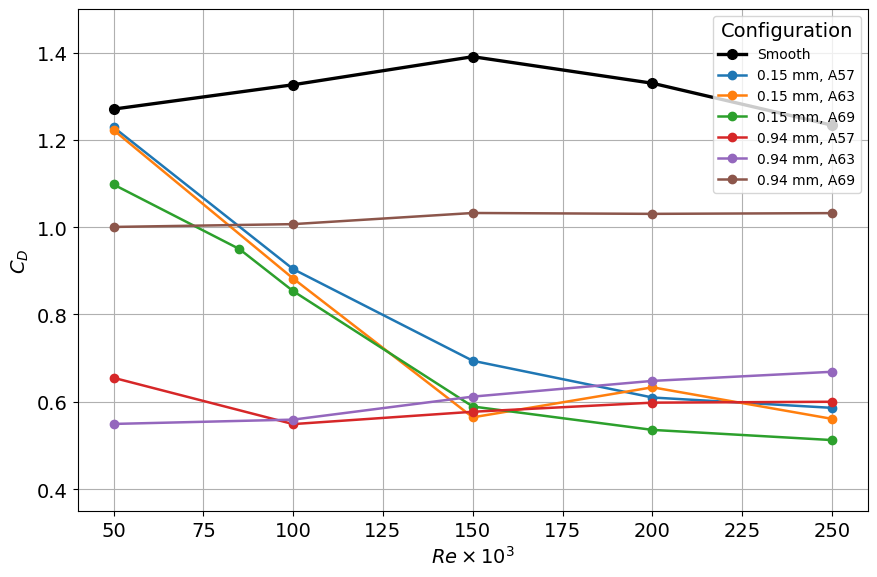

In [35]:
# Example: C_D vs Re for clean cylinder and the 0.94 mm trip wire.
# Edit angles as needed.
plot_cd_vs_re(
    results_df,
    trip_mm=[0.94,0.15],
    include_clean=True,
    angles=[57,63,69],
    annotate=False,
    ylim=(0.35, 1.5),
    show_values = False,
    show_errorbars = False,
    show_title = False,
)


### For specific runs at different angles

In [9]:
selected_mask = (
    (
        (results_df["case"] == "Trip")
        & np.isclose(results_df["trip_mm"], 0.15)
        & results_df["angle"].isin([57, 63, 69])
    )
    |
    (
        (results_df["case"] == "Trip")
        & np.isclose(results_df["trip_mm"], 0.94)
        & results_df["angle"].isin([27, 33])
    )
)

selected_df = results_df[selected_mask].copy()


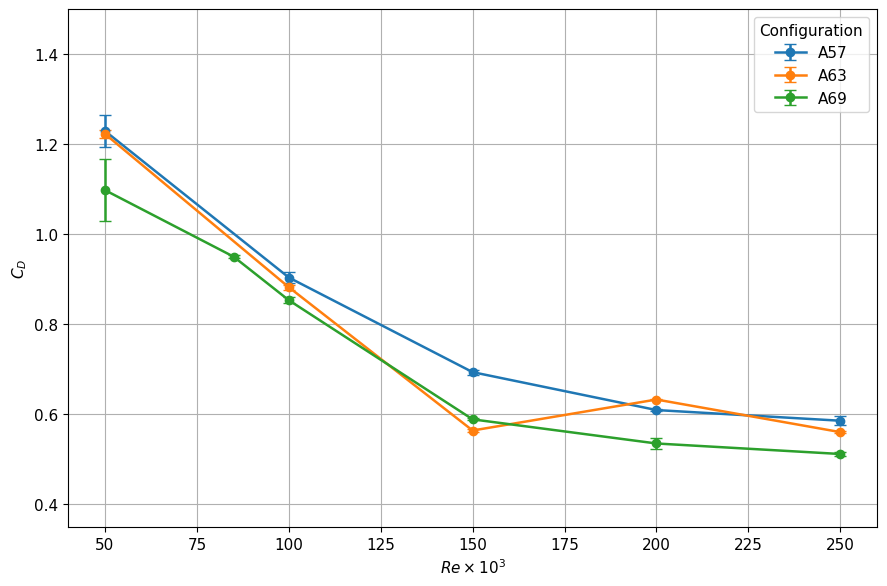

In [10]:
plot_cd_vs_re(
    selected_df,
    trip_mm=[0.15, 0.94],
    include_clean = True,
    angles=[57, 63, 69],
    show_errorbars=True,
    show_values=False,
    show_title=False,
    ylim=(0.35, 1.5),
)


### $C_L$ plot 

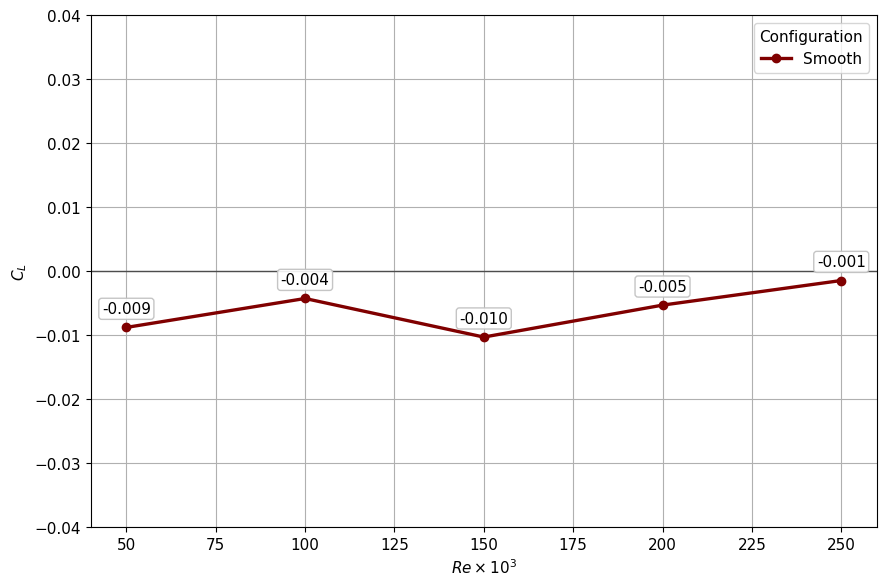

In [11]:
# Example: C_L vs Re.
plot_cl_vs_re(
    results_df,
    trip_mm=0.94,
    include_clean=True,
    angles=[],
    ylim=(-0.04, 0.04),
    show_values = True,
    show_errorbars = False,
    show_title = False,
)


### $St$ plot (5 segments)

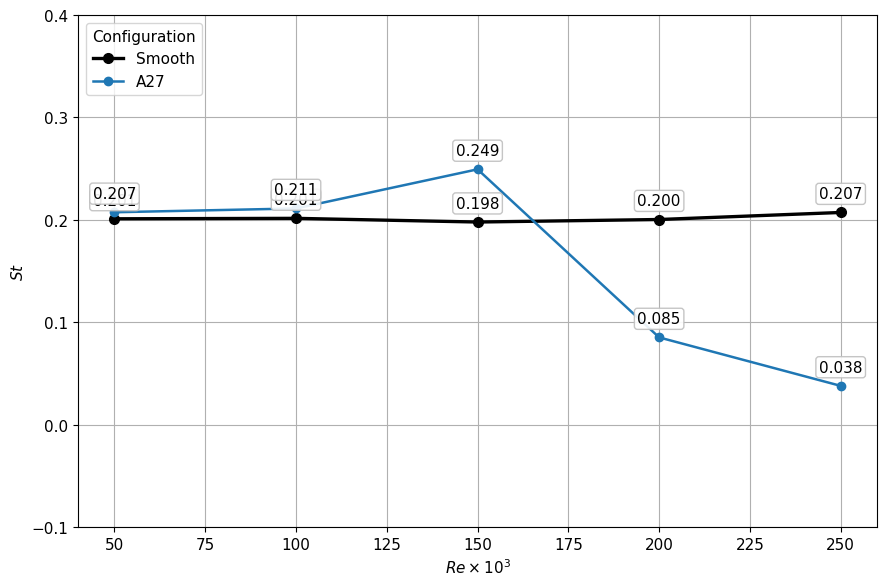

In [12]:
# Example: Strouhal number vs Re.
plot_st_vs_re(
    results_df,
    include_clean=True,
    angles=[27],
    ylim=(-0.1, 0.4),
    show_values=True,
    show_errorbars=False,
    show_title=False,
)


### $St$ vs Reynolds, 1 segment

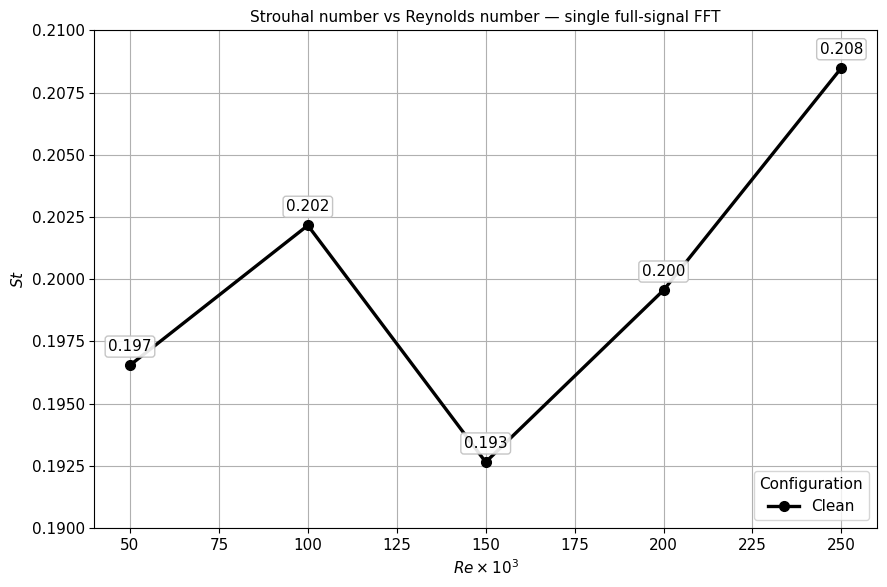

In [13]:
plot_single_st_vs_re(
    results_df,
    include_clean=True,
    angles=[],
    ylim=(0.190, 0.210),
    show_values=True,
)


### $Lift$ and $FFT$ plot 

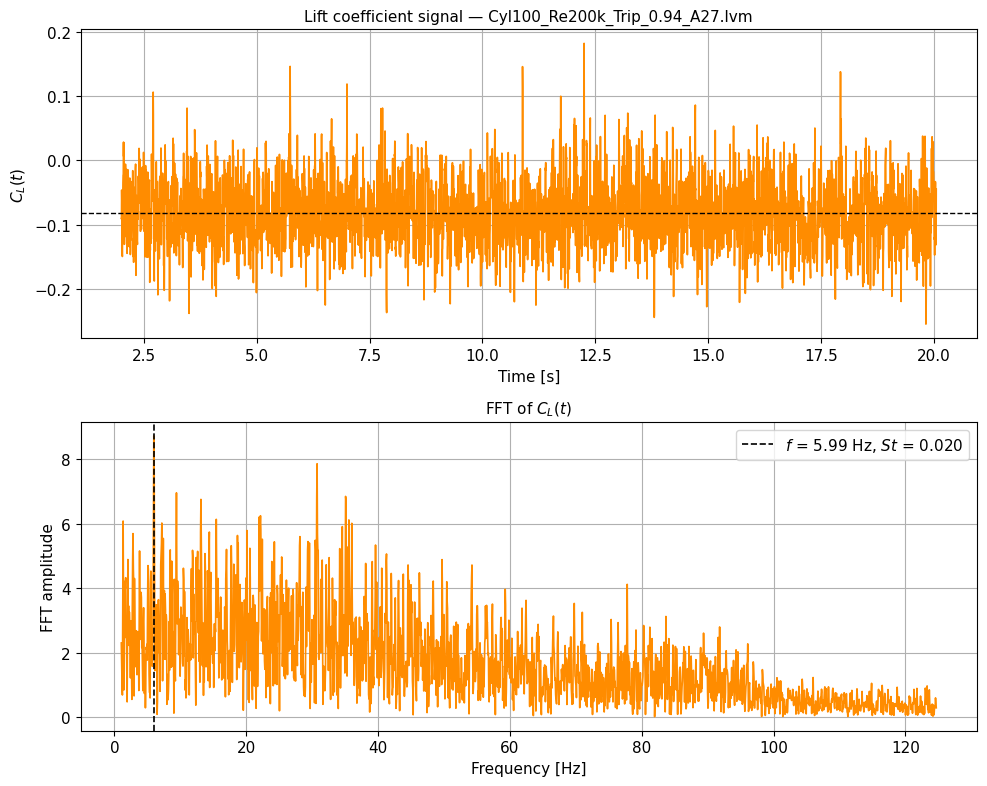

In [14]:
plot_lift_signal_and_fft(("Trip", "0.94", "27"), "Re200k")


### $Lift$ and $FFT$ 5 segments

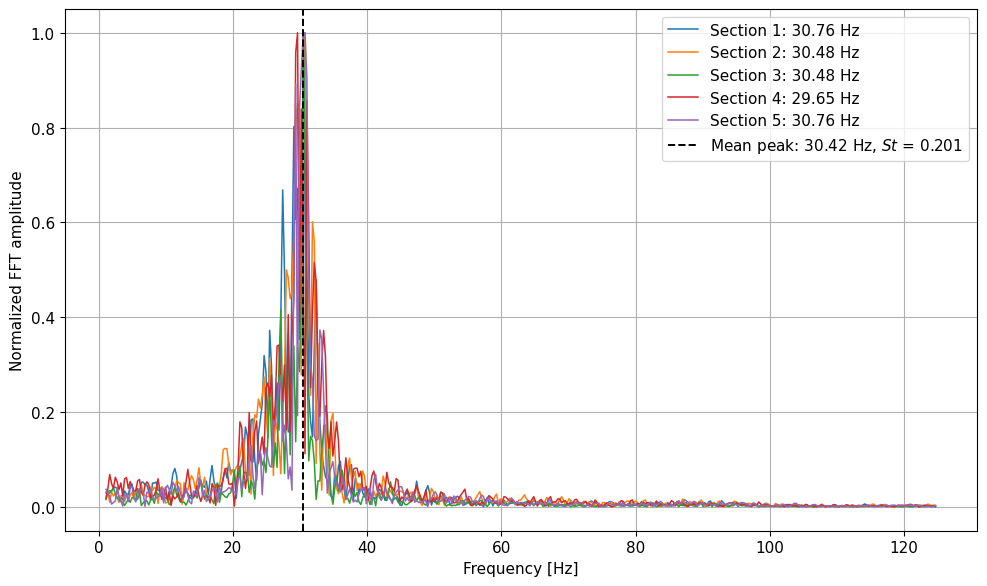

Dominant frequencies by section [Hz]:
Section 1: 30.760 Hz
Section 2: 30.479 Hz
Section 3: 30.480 Hz
Section 4: 29.648 Hz
Section 5: 30.756 Hz

Mean frequency: 30.424 Hz
Mean Strouhal number: 0.2014


In [15]:
plot_lift_fft_segments(("Clean",), "Re100k", n_segments=5,show_title=False)


### $C_P$ distribution plot 

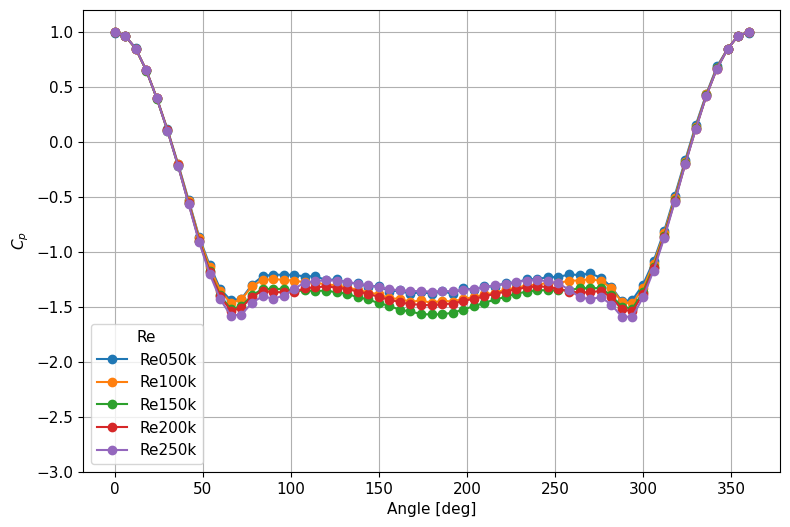

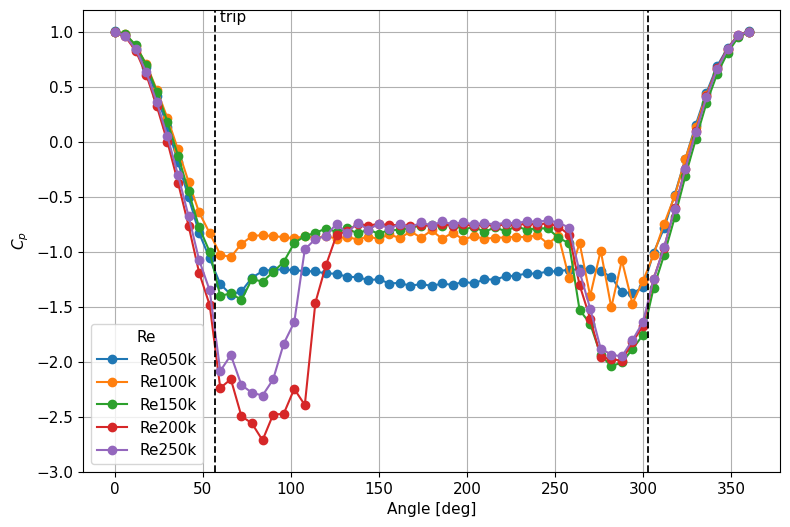

In [16]:
# Example: Cp distribution for one group.
# For clean:
plot_cp_distribution(("Clean",), target_re=None, ylim=(-3.0, 1.2), show_title=False)

# For trip wire, uncomment and edit:
plot_cp_distribution(("Trip", "0.15", "57"), target_re=None, ylim=(-3.0, 1.2),show_title=False)


### Variance and RMS

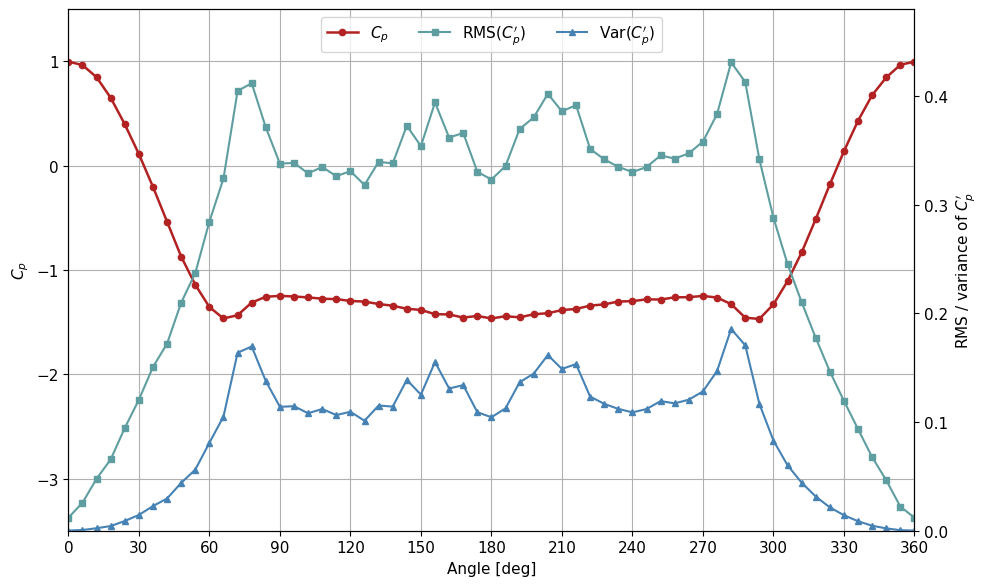

In [17]:
plot_cp_rms_variance(("Clean",), "Re100k", ylim_cp=(-3.5, 1.5), ylim_stats=(0, 0.48), show_title=False)


# All plots
# for run in get_runs(("Clean",)):
#     plot_cp_rms_variance(("Clean",), run["re"])


### $C_P$ around the cylinder plot 

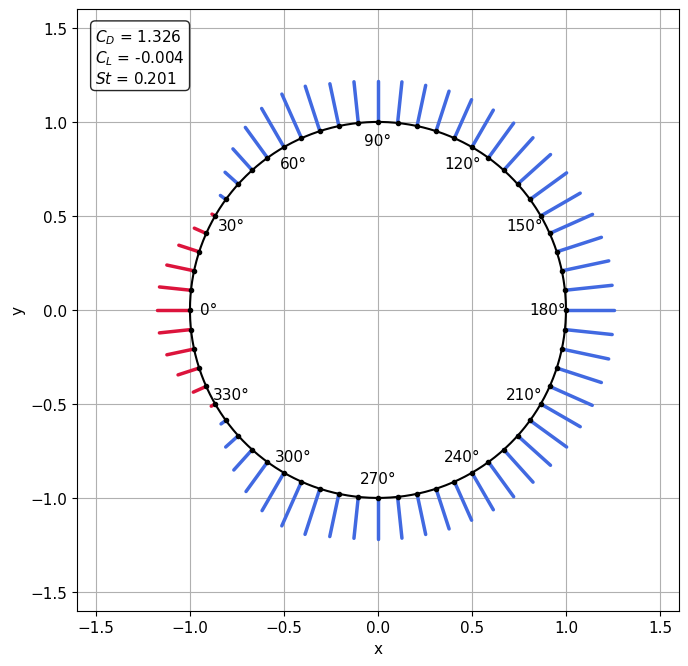

In [18]:
# Example: normal-bar plot for one run.
# Fixed cp_abs_max makes plots comparable across cases.
plot_cp_normal_bars(
    target_key=("Clean",),
    target_re="Re100k",
    cp_abs_max=2.0,
    use_magnitude=True,
    show_title=False,
)

# For a trip-wire case, uncomment and edit:
# plot_cp_normal_bars(
#     target_key=("Trip", "0.94", "27"),
#     target_re="Re100k",
#     cp_abs_max=2.0,
#     use_magnitude=True,
# )


### $C_P$ around the cylinder comparison plot 

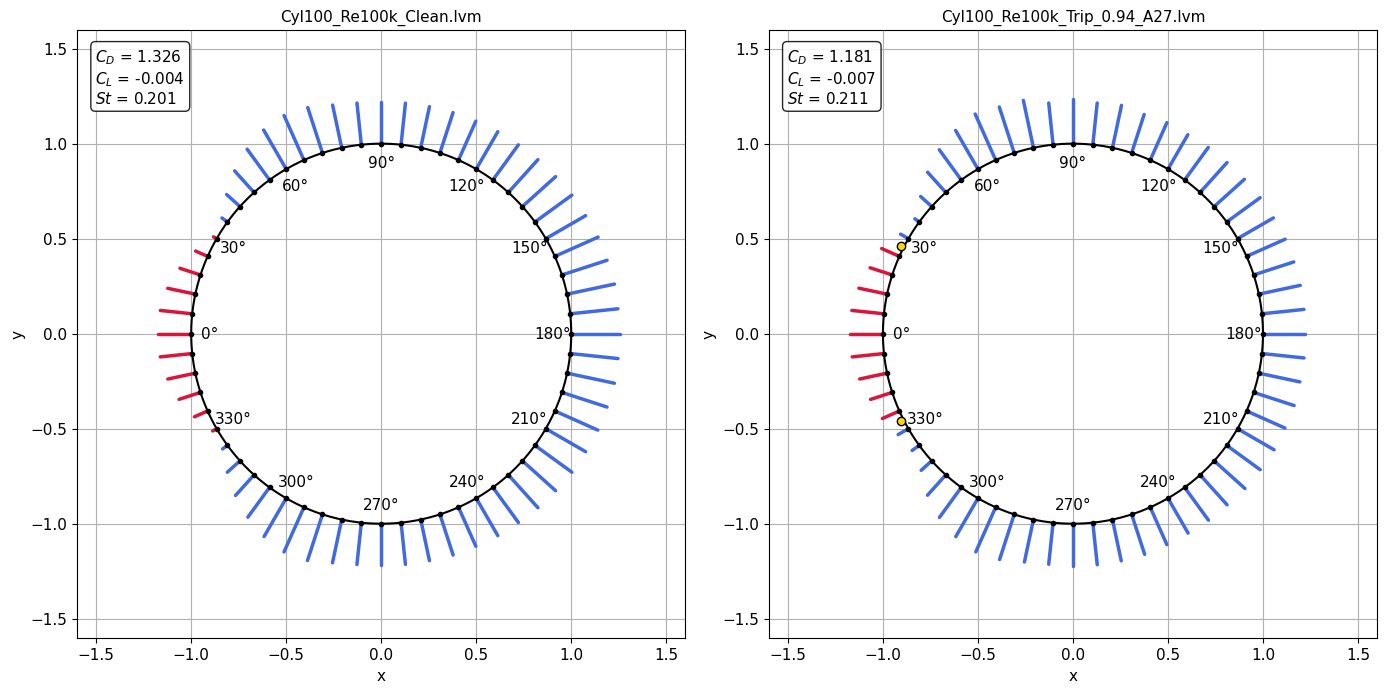

In [19]:
# Example: compare clean and trip side by side.
# Requires the selected trip case to exist in DATA_FOLDER.
compare_cp_normal_bars(
    target_key_1=("Clean",),
    target_re_1="Re100k",
    target_key_2=("Trip", "0.94", "27"),
    target_re_2="Re100k",
    cp_abs_max=2.0,
    use_magnitude=True,
)


### Specific file analysis plot

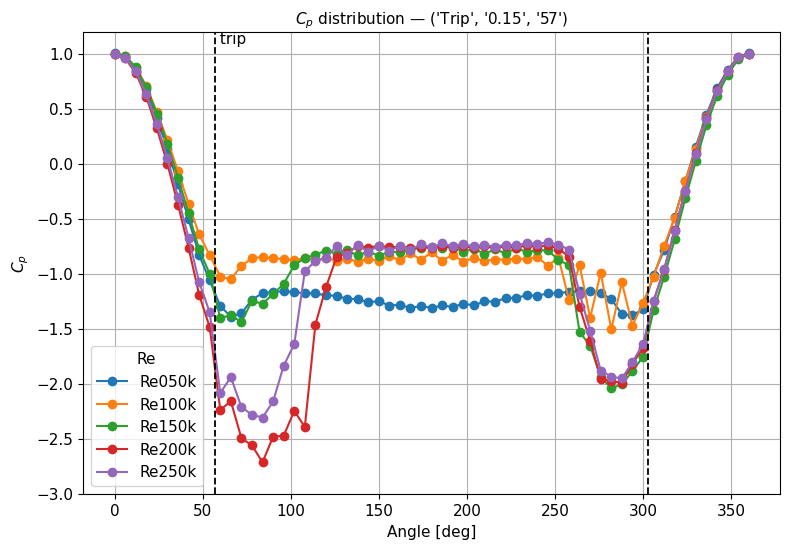

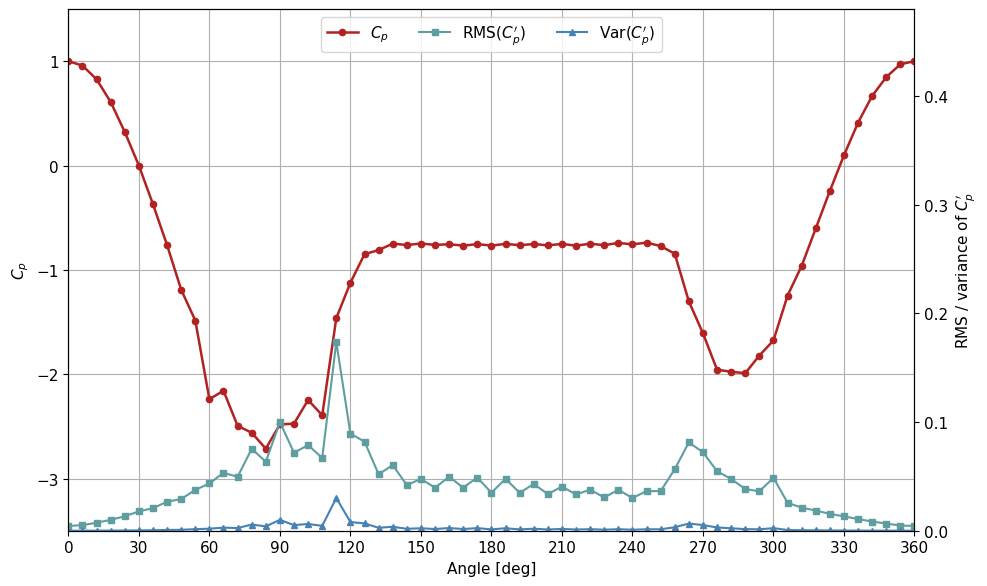

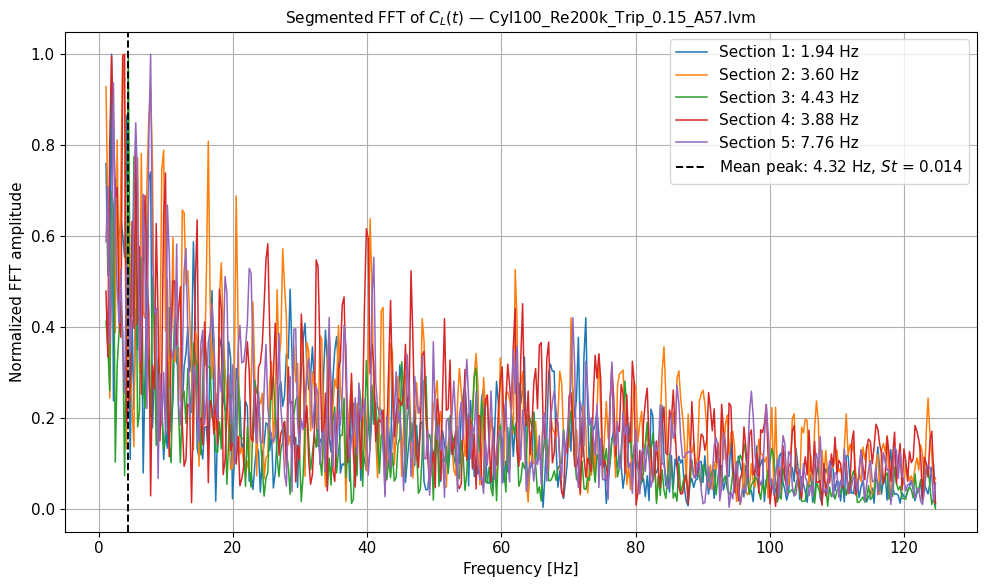

Dominant frequencies by section [Hz]:
Section 1: 1.939 Hz
Section 2: 3.602 Hz
Section 3: 4.433 Hz
Section 4: 3.879 Hz
Section 5: 7.759 Hz

Mean frequency: 4.323 Hz
Mean Strouhal number: 0.0143


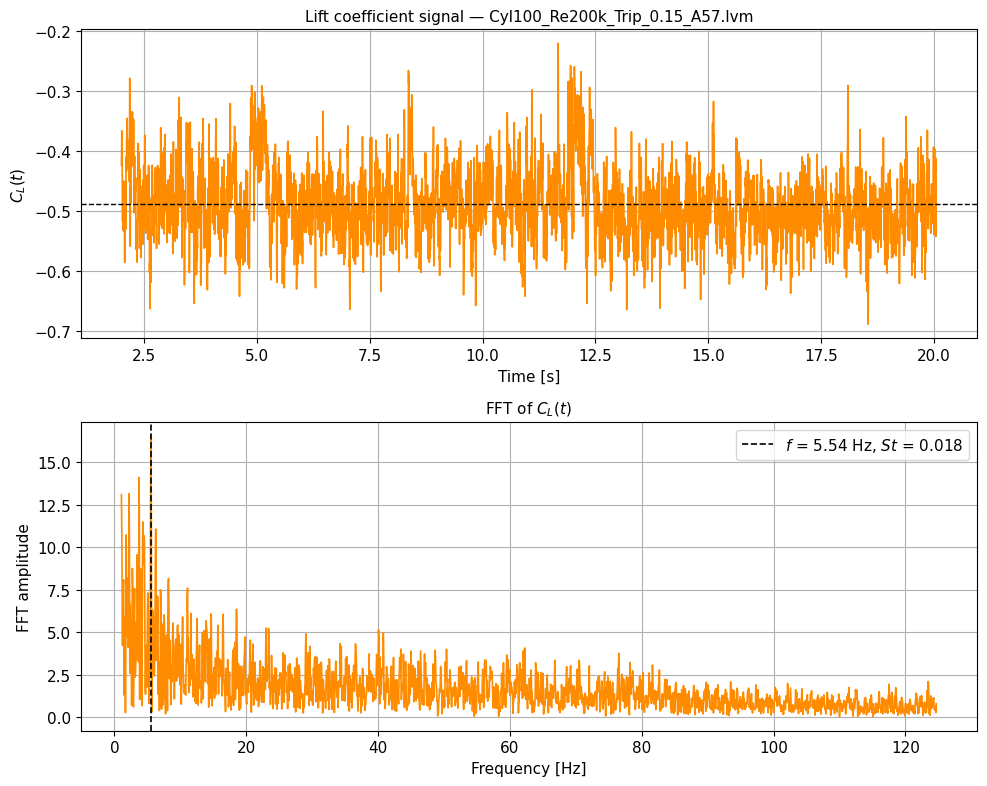

In [20]:
plot_cp_distribution(("Trip", "0.15", "57"))
plot_cp_rms_variance(("Trip", "0.15", "57"), "Re200k", ylim_cp=(-3.5, 1.5), ylim_stats=(0, 0.48), show_title=False)
plot_lift_fft_segments(("Trip", "0.15", "57"), "Re200k", n_segments=5)
plot_lift_signal_and_fft(("Trip", "0.15", "57"), "Re200k")


### $Uncertaincy$ plot 

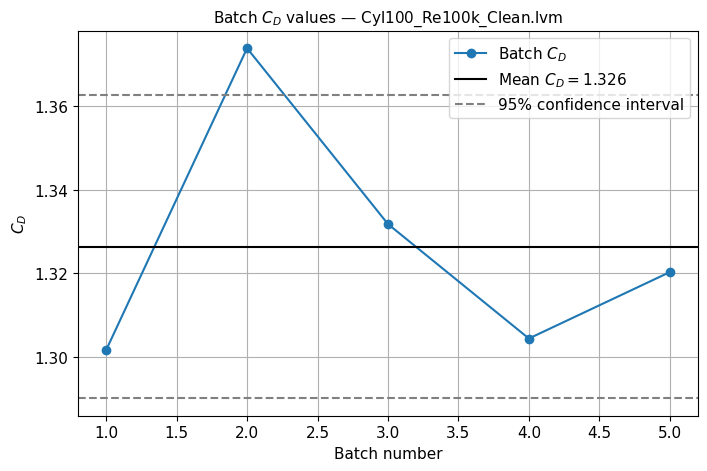

C_D = 1.3264 ± 0.0363
Batch 1: C_D = 1.3017
Batch 2: C_D = 1.3739
Batch 3: C_D = 1.3318
Batch 4: C_D = 1.3044
Batch 5: C_D = 1.3203


In [21]:
# Example: batch uncertainty plot for one run.
plot_batch_cd(("Clean",), "Re100k")


### $Uncertaincy$ plot 2

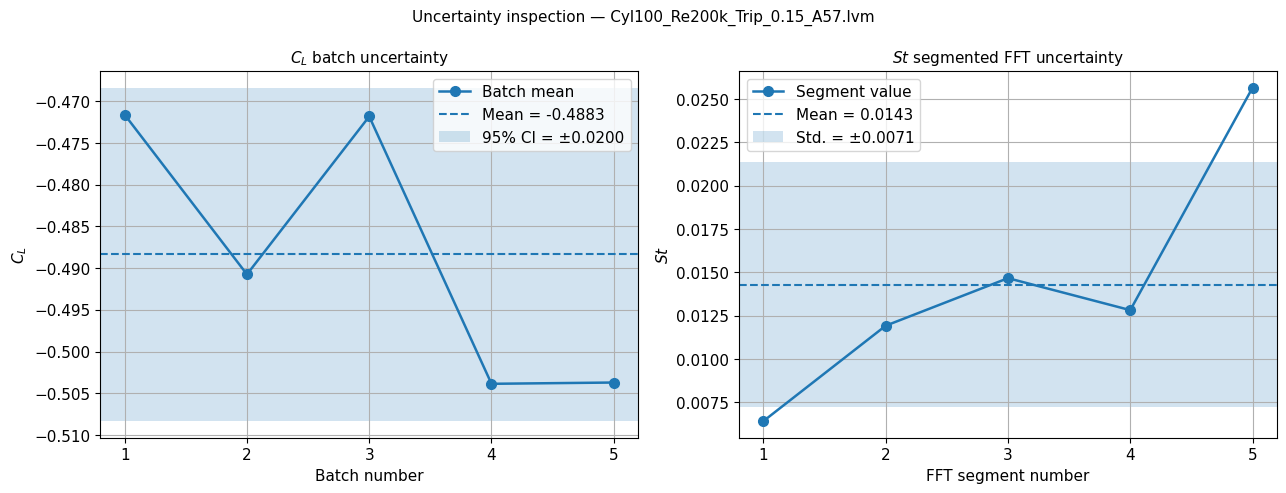

Cyl100_Re200k_Trip_0.15_A57.lvm

C_L batch values:


,batch,C_L_mean
0,1,-0.471601
1,2,-0.490743
2,3,-0.471805
3,4,-0.503861
4,5,-0.503709


C_L mean:     -0.48834
C_L std:      0.01610
C_L 95% CI:   ±0.01998

St segment values:


,segment,f_shedding,U_mean,St
0,1,1.939500,30.180552,0.006426
1,2,3.602236,30.200832,0.011928
2,3,4.433462,30.221716,0.014670
3,4,3.879288,30.248052,0.012825
4,5,7.758539,30.239923,0.025657


St mean:      0.01430
St std:       0.00705


(   batch  C_L_mean
 0      1 -0.471601
 1      2 -0.490743
 2      3 -0.471805
 3      4 -0.503861
 4      5 -0.503709,
    segment  f_shedding     U_mean        St
 0        1    1.939500  30.180552  0.006426
 1        2    3.602236  30.200832  0.011928
 2        3    4.433462  30.221716  0.014670
 3        4    3.879288  30.248052  0.012825
 4        5    7.758539  30.239923  0.025657)

In [22]:
plot_cl_st_uncertainty_batches(("Trip", "0.15", "57"), "Re200k")


## 7. Inspect extra channels

In [23]:
def summarize_extra_channels(target_key=None, target_re=None):
    """
    Summarize pitot, tunnel velocity, density, time, etc.

    target_key=None gives all runs.
    """
    selected_runs = runs

    if target_key is not None:
        selected_runs = get_runs(target_key, target_re=target_re)

    rows = []

    for run in selected_runs:
        extra = run["extra_data"]

        for col in EXTRA_NAMES:
            s = extra[col]
            rows.append({
                "file": run["file_name"],
                "re": run["re"],
                "case": run["case"],
                "trip_mm": run["trip_mm"],
                "angle": run["angle"],
                "variable": col,
                "mean": s.mean(),
                "std": s.std(),
                "min": s.min(),
                "max": s.max(),
            })

    return pd.DataFrame(rows)


extra_summary = summarize_extra_channels()
display(extra_summary.head(20))


,file,re,case,trip_mm,angle,variable,mean,std,min,max
0,Cyl100_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,pitot,33.411589,9.688379e-01,27.235083,39.287693
1,Cyl100_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,AoA,0.001000,2.168621e-19,0.001000,0.001000
2,Cyl100_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,F,-4.947512,2.475315e-02,-5.046244,-4.802736
3,Cyl100_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,alpha,0.662767,2.941364e-02,0.574985,0.875466
4,Cyl100_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,P_m,33.415787,1.845029e-01,33.041113,34.107964
5,Cyl100_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,V_tunnel,7.470972,2.058903e-02,7.428998,7.547981
6,Cyl100_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,rho,1.197358,0.000000e+00,1.197358,1.197358
7,Cyl100_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,time,10.023218,5.787465e+00,-0.000042,20.045490
8,Cyl100_Re050k_Trip_0.15_A57.lvm,Re050k,Trip,0.15,57.0,pitot,33.322158,9.552669e-01,26.965494,39.238377
9,Cyl100_Re050k_Trip_0.15_A57.lvm,Re050k,Trip,0.15,57.0,AoA,0.001000,2.168621e-19,0.001000,0.001000


In [24]:
# Optional: plot one extra channel across all runs.
def plot_extra_channel(channel="pitot", target_key=None, show_title=True):
    selected_runs = runs if target_key is None else get_runs(target_key)

    fig, ax = plt.subplots(figsize=(10, 5))

    for run in selected_runs:
        ax.plot(
            run["extra_data"].index,
            run["extra_data"][channel],
            label=run["file_name"],
            alpha=0.9,
        )

    ax.set_xlabel("Sample number")
    ax.set_ylabel(channel)
    if show_title:
        ax.set_title(f"{channel} across selected files")
    ax.grid(True)
    ax.legend()
    plt.show()


# Example:
# plot_extra_channel("pitot")
# plot_extra_channel("V_tunnel", target_key=("Clean",))


## 8. Notes

Important assumptions in this notebook:

1. The dynamic pressure channel is column 64 in 1-based indexing, i.e. Python index `63`.
2. Layer 1 is interpreted as the taps at \(0^\circ, 12^\circ, \ldots, 348^\circ\).
3. Layer 2 is interpreted as the taps at \(6^\circ, 18^\circ, \ldots, 354^\circ\).
4. \(C_D\) and \(C_L\) use the same sign convention as your previous working notebook.
5. The Strouhal number is computed from the time-resolved \(C_L(t)\) signal. This is often more robust than using a single pressure tap, but it may differ slightly from Gamst's tap-based method.

If you want strict consistency with Gamst's method, the next useful addition would be a second Strouhal calculation based on a chosen pressure tap, for example tap 24 / approximately \(138^\circ\), and then comparing it against the \(C_L(t)\)-based value.


In [25]:


results_day1 = results_df.copy()
results_day1["test_day"] = "Day 1"
results_day1.to_csv("results_day1.csv", index=False)
